In [96]:
#!pip install pandas numpy matplotlib
#!pip install seaborn
#!pip install os

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

# 1. Thiết lập đường dẫn (dấu '.' nếu file nằm cùng thư mục với code)
path = '.' 

# 2. Lấy danh sách tất cả file kết thúc bằng .csv
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# 3. Đọc tất cả vào một Dictionary
# Key là tên file (bỏ đuôi .csv), Value là nội dung bảng (DataFrame)
data = {f[:-4]: pd.read_csv(os.path.join(path, f)) for f in files}

# 4. Kiểm tra các bảng đã đọc được
print("Các bảng đã load thành công:", data.keys())

Các bảng đã load thành công: dict_keys(['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'sample_submission', 'shipments', 'web_traffic'])


            tong_von_chon  avg_stock_on_hand  avg_sell_through  n_snapshots
category_x                                                                 
Streetwear   3.255224e+10             236.94              0.09        23242
Outdoor      7.879571e+09             273.49              0.08        16809
Casual       1.086290e+09             116.48              0.10         2543
GenZ         8.212938e+08             167.49              0.09         3348

=== TOP 15 SẢN PHẨM CHÔN VỐN NHIỀU NHẤT ===
   product_name_x category_x  tong_von_chon  avg_stock  avg_sell_through  avg_days_supply
HanoiStreet UM-10 Streetwear   2.059782e+09    1362.53              0.06          1016.10
 SaigonFlex UM-92 Streetwear   1.021668e+09    1544.08              0.08          4889.01
    UrbanVN UE-14 Streetwear   8.926773e+08    1098.17              0.06          2057.91
 SaigonFlex UC-69 Streetwear   8.563379e+08    1680.88              0.06          2551.86
HanoiStreet UE-36 Streetwear   8.294121e+08    13

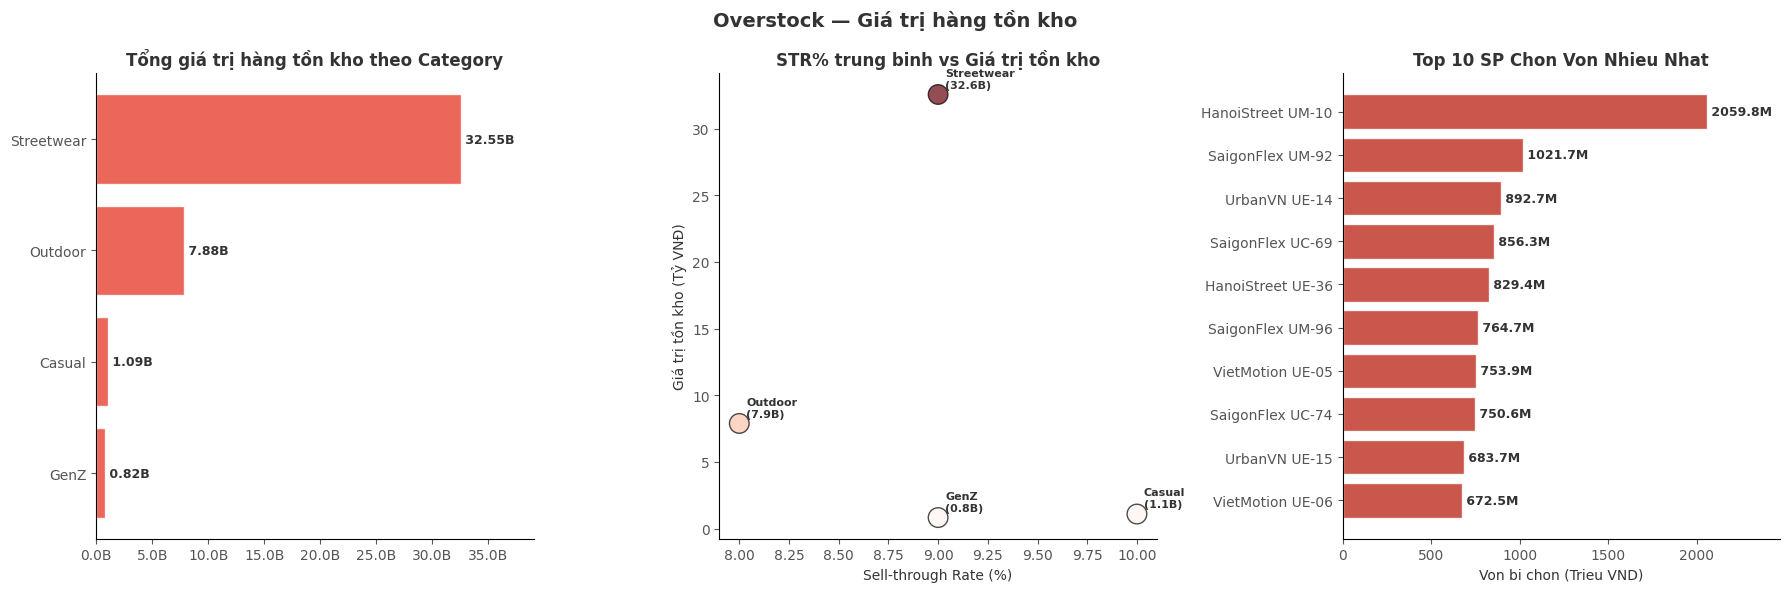

Tong von bi chon (tat ca overstock): 42,339,396,895 VND
Category chon nhieu nhat: 32,552,242,382 VND (Streetwear)
Category sell-through thap nhat: 8.0% (Outdoor)


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # ← dòng này bị thiếu

# Đọc các bảng chính
customers   = pd.read_csv("customers.csv")
inventory   = pd.read_csv("inventory.csv")
orders      = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products    = pd.read_csv("products.csv")
returns     = pd.read_csv("returns.csv")
shipments   = pd.read_csv("shipments.csv")

# Đọc các bảng bổ trợ
geography   = pd.read_csv("geography.csv")
payments    = pd.read_csv("payments.csv")
promotions  = pd.read_csv("promotions.csv")
reviews     = pd.read_csv("reviews.csv")
sales       = pd.read_csv("sales.csv")
web_traffic = pd.read_csv("web_traffic.csv")

# TIER 1 - #2: OVERSTOCK → VỐN BỊ CHÔN TRONG KHO
# Vốn bị chôn = stock_on_hand × cogs

inventory = pd.read_csv("inventory.csv")
products  = pd.read_csv("products.csv")

inv = inventory.merge(products[["product_id","product_name","category","segment","cogs"]], on="product_id", how="left")
inv["capital_locked"] = inv["stock_on_hand"] * inv["cogs"]

overstock = inv[inv["overstock_flag"] == 1]

if 'category' not in overstock.columns and overstock.index.name == 'category':
    df_temp = overstock.reset_index()
else:
    df_temp = overstock.copy()

category_col = "category_x" if "category_x" in df_temp.columns else "category"
if category_col not in df_temp.columns:
    raise KeyError(f"Khong tim thay cot category. Cac cot hien co: {df_temp.columns.tolist()}")

cat_locked = df_temp.groupby(category_col).agg(
    tong_von_chon     = ("capital_locked",   "sum"),
    avg_stock_on_hand = ("stock_on_hand",    "mean"),
    avg_sell_through  = ("sell_through_rate","mean"),
    n_snapshots       = ("product_id",       "count"),
).round(2).sort_values("tong_von_chon", ascending=False)

print(cat_locked)

top_locked = overstock.groupby(["product_id","product_name_x","category_x"]).agg(
    tong_von_chon    = ("capital_locked",    "sum"),
    avg_stock        = ("stock_on_hand",     "mean"),
    avg_sell_through = ("sell_through_rate", "mean"),
    avg_days_supply  = ("days_of_supply",    "mean"),
).reset_index().nlargest(15, "tong_von_chon").round(2)

print("\n=== TOP 15 SẢN PHẨM CHÔN VỐN NHIỀU NHẤT ===")
print(top_locked[["product_name_x","category_x","tong_von_chon","avg_stock","avg_sell_through","avg_days_supply"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Overstock — Giá trị hàng tồn kho", fontsize=14, fontweight="bold")

ax = axes[0]
bars1 = ax.barh(cat_locked.index, cat_locked["tong_von_chon"],
                color="#E74C3C", edgecolor="white", alpha=0.85)
for bar in bars1:
    w = bar.get_width()
    label = f"{w/1e9:.2f}B" if w >= 1e8 else f"{w/1e6:.1f}M"
    ax.text(w, bar.get_y() + bar.get_height()/2, f" {label}", va="center", fontsize=9, fontweight="bold")
ax.set_title("Tổng giá trị hàng tồn kho theo Category", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))
ax.set_xlim(right=cat_locked["tong_von_chon"].max() * 1.2)
ax.invert_yaxis()

ax = axes[1]
sc = ax.scatter(cat_locked["avg_sell_through"] * 100, cat_locked["tong_von_chon"] / 1e9,
                s=200, c=cat_locked["tong_von_chon"], cmap="Reds", edgecolors="black", alpha=0.7)
for idx, row in cat_locked.iterrows():
    val_label = f"{row['tong_von_chon']/1e9:.1f}B"
    ax.annotate(f"{idx}\n({val_label})",
                (row["avg_sell_through"] * 100, row["tong_von_chon"] / 1e9),
                xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="semibold")
ax.set_title("STR% trung binh vs Giá trị tồn kho", fontweight="bold")
ax.set_xlabel("Sell-through Rate (%)")
ax.set_ylabel("Giá trị tồn kho (Tỷ VNĐ)")

ax = axes[2]
top10 = top_locked.head(10)
bars3 = ax.barh(top10["product_name_x"].str[:20], top10["tong_von_chon"] / 1e6,
                color="#C0392B", edgecolor="white", alpha=0.85)
for bar in bars3:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f" {w:.1f}M", va="center", fontsize=9, fontweight="bold")
ax.set_title("Top 10 SP Chon Von Nhieu Nhat", fontweight="bold")
ax.set_xlabel("Von bi chon (Trieu VND)")
ax.set_xlim(right=top10["tong_von_chon"].max() / 1e6 * 1.2)
ax.invert_yaxis()

for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

tong_von = overstock["capital_locked"].sum()
print(f"Tong von bi chon (tat ca overstock): {tong_von:,.0f} VND")
print(f"Category chon nhieu nhat: {cat_locked['tong_von_chon'].iloc[0]:,.0f} VND ({cat_locked.index[0]})")
print(f"Category sell-through thap nhat: {cat_locked['avg_sell_through'].min()*100:.1f}% ({cat_locked['avg_sell_through'].idxmin()})")

=== DOANH THU BỊ MẤT DO STOCKOUT THEO CATEGORY ===
            doanh_thu_mat  so_don  avg_stockout_days
category                                            
Streetwear   8.834092e+09  264907               2.23
Outdoor      1.693738e+09  176256               2.27
Casual       3.083494e+08   16111               2.15
GenZ         2.350965e+08   25498               2.02


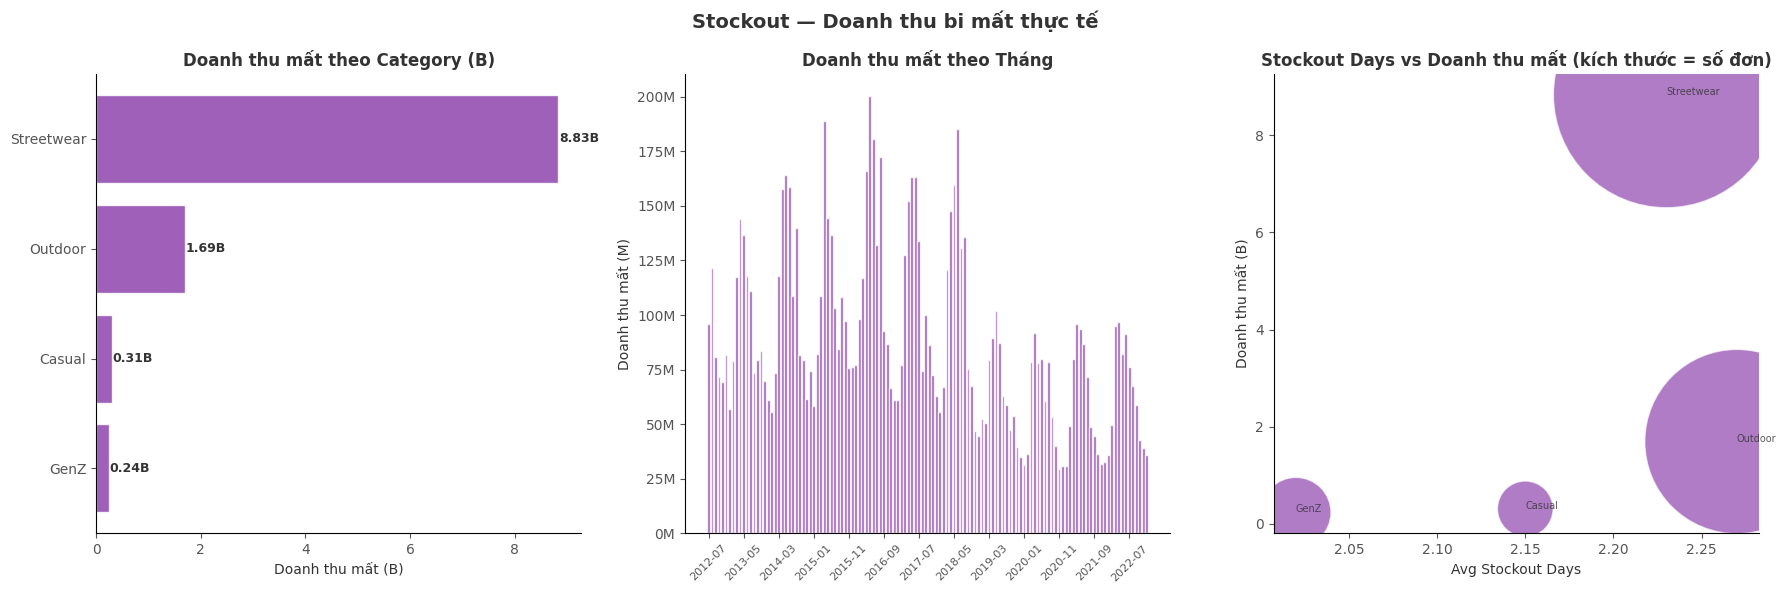

Tổng doanh thu bị mất do Stockout : 11,071,275,996 VNĐ
Số đơn hàng bị ảnh hưởng          : 482,772 đơn
Category bị ảnh hưởng nhiều nhất  : 8,834,091,654 VNĐ (Streetwear)


In [99]:
# TIER 1 - #1: STOCKOUT → DOANH THU BỊ MẤT THỰC TẾ
# Khi stockout_flag=1, đơn hàng nào bị ảnh hưởng cùng thời điểm?

inventory = pd.read_csv("inventory.csv")
orders = pd.read_csv("orders.csv")

# Chuẩn bị thời gian
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["year_month"] = orders["order_date"].dt.to_period("M")
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["year_month"]    = inventory["snapshot_date"].dt.to_period("M")

# Lấy các product + tháng có stockout
stockout = inventory[inventory["stockout_flag"] == 1][["product_id","year_month","stockout_days"]].drop_duplicates()

# Join order_items + orders để lấy year_month của đơn hàng
oi = order_items.merge(orders[["order_id","year_month"]], on="order_id", how="left")
oi["revenue"] = oi["quantity"] * oi["unit_price"]

# Join với stockout để tìm đơn hàng trong tháng stockout
affected = oi.merge(stockout, on=["product_id","year_month"], how="inner")

# Tổng doanh thu bị mất
lost_rev_cat = affected.merge(products[["product_id","category"]], on="product_id", how="left")
lost_by_cat  = lost_rev_cat.groupby("category").agg(
    doanh_thu_mat = ("revenue",      "sum"),
    so_don        = ("order_id",     "count"),
    avg_stockout_days = ("stockout_days","mean"),
).round(2).sort_values("doanh_thu_mat", ascending=False)

print("=== DOANH THU BỊ MẤT DO STOCKOUT THEO CATEGORY ===")
print(lost_by_cat.to_string())

lost_by_month = affected.groupby("year_month").agg(
    doanh_thu_mat = ("revenue",   "sum"),
    so_don        = ("order_id",  "count"),
).reset_index()
lost_by_month["year_month_str"] = lost_by_month["year_month"].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Stockout — Doanh thu bi mất thực tế", fontsize=14, fontweight="bold")

# Chart 1: Doanh thu mất theo Category
ax = axes[0]
bars = ax.barh(lost_by_cat.index, lost_by_cat["doanh_thu_mat"] / 1e9,
               color="#8E44AD", edgecolor="white", alpha=0.85)
ax.set_title("Doanh thu mất theo Category (B)", fontweight="bold")
ax.set_xlabel("Doanh thu mất (B)")
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}B", va="center", fontsize=9, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Xu hướng doanh thu mất theo tháng
ax = axes[1]
step = max(1, len(lost_by_month) // 12)
ax.bar(range(len(lost_by_month)), lost_by_month["doanh_thu_mat"] / 1e6,
       color="#8E44AD", edgecolor="white", alpha=0.8)
ax.set_xticks(range(0, len(lost_by_month), step))
ax.set_xticklabels(lost_by_month["year_month_str"].iloc[::step], rotation=45, fontsize=8)
ax.set_title("Doanh thu mất theo Tháng", fontweight="bold")
ax.set_ylabel("Doanh thu mất (M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 3: Stockout days vs doanh thu mất (scatter theo category)
ax = axes[2]
ax.scatter(lost_by_cat["avg_stockout_days"], lost_by_cat["doanh_thu_mat"] / 1e9,
           s=lost_by_cat["so_don"] / 10, color="#8E44AD", alpha=0.7, edgecolors="white")
for idx, row in lost_by_cat.iterrows():
    ax.annotate(str(idx)[:12], (row["avg_stockout_days"], row["doanh_thu_mat"] / 1e9),
                fontsize=7, alpha=0.8)
ax.set_title("Stockout Days vs Doanh thu mất (kích thước = số đơn)", fontweight="bold")
ax.set_xlabel("Avg Stockout Days")
ax.set_ylabel("Doanh thu mất (B)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

tong_mat = affected["revenue"].sum()
print(f"Tổng doanh thu bị mất do Stockout : {tong_mat:,.0f} VNĐ")
print(f"Số đơn hàng bị ảnh hưởng          : {len(affected):,} đơn")
print(f"Category bị ảnh hưởng nhiều nhất  : {lost_by_cat['doanh_thu_mat'].iloc[0]:,.0f} VNĐ ({lost_by_cat.index[0]})")


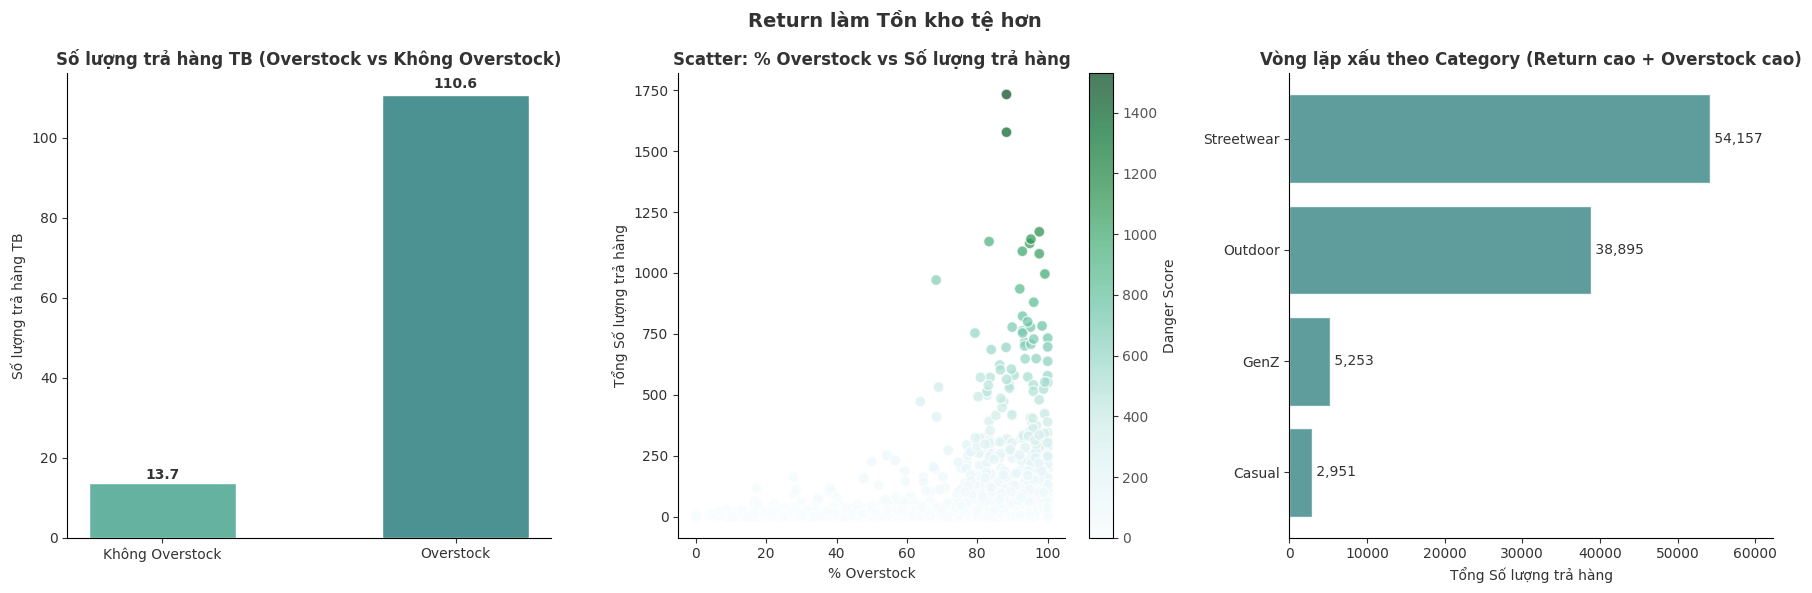

In [100]:
PASTEL_PALETTE = ["#4D9292", "#66B2A1", "#80C9A5", "#99E1A9", "#C2F0C5"]
DARK_TEAL = "#4D9292"
TEXT_COLOR = "#333333"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Return làm Tồn kho tệ hơn", fontsize=14, fontweight="bold", color=TEXT_COLOR)

# Chart 1: Return qty theo overstock vs không
ax = axes[0]
ret_compare = danger.groupby("is_overstock")["tong_return_qty"].mean()
ret_compare.index = ["Không Overstock", "Overstock"]

bars = ax.bar(ret_compare.index, ret_compare.values,
              color=[PASTEL_PALETTE[1], PASTEL_PALETTE[0]],  # nhẹ vs đậm
              width=0.5, edgecolor="white")

ax.set_title("Số lượng trả hàng TB (Overstock vs Không Overstock)", fontweight="bold", color=TEXT_COLOR)
ax.set_ylabel("Số lượng trả hàng TB", color=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom",
            fontweight="bold", color=TEXT_COLOR)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Scatter — return qty vs pct_overstock
ax = axes[1]
sc = ax.scatter(danger["pct_overstock"] * 100,
                danger["tong_return_qty"],
                c=danger["danger_score"],
                cmap="BuGn",   # hợp pastel xanh
                s=60, alpha=0.7,
                edgecolors="white")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Danger Score", color=TEXT_COLOR)
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)

ax.set_title("Scatter: % Overstock vs Số lượng trả hàng", fontweight="bold", color=TEXT_COLOR)
ax.set_xlabel("% Overstock", color=TEXT_COLOR)
ax.set_ylabel("Tổng Số lượng trả hàng", color=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 3: Vòng lặp xấu theo category
ax = axes[2]
bars = ax.barh(bad_loop_cat.index,
               bad_loop_cat["tong_return_qty"],
               color=PASTEL_PALETTE[0],  # màu chủ đạo
               edgecolor="white",
               alpha=0.9)

for bar in bars:
    width = bar.get_width()
    ax.text(width,
            bar.get_y() + bar.get_height()/2,
            f' {int(width):,}',
            va='center',
            fontsize=10,
            color=TEXT_COLOR)

ax.set_title("Vòng lặp xấu theo Category (Return cao + Overstock cao)",
             fontweight="bold", color=TEXT_COLOR)
ax.set_xlabel("Tổng Số lượng trả hàng", color=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)

ax.set_xlim(right=bad_loop_cat["tong_return_qty"].max() * 1.15)
ax.invert_yaxis()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

=== THANG CO TRAFFIC CAO + TON KHO THAP (< 14 ngay) ===
So thang mat co hoi: 0 / 120


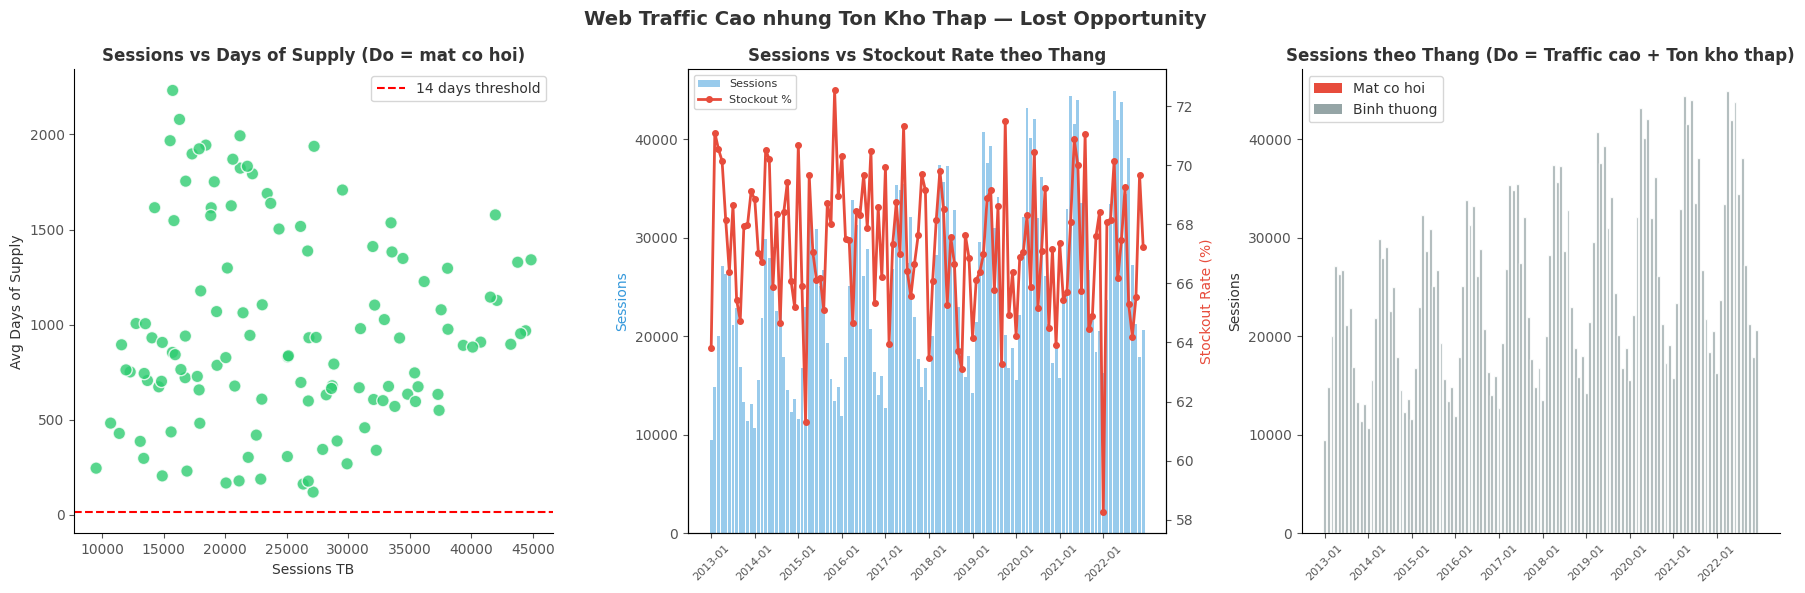

In [101]:
# TIER 2 - #5: WEB TRAFFIC CAO NHƯNG TỒN KHO THẤP = MẤT CƠ HỘI
# Tháng sessions tăng mà days_of_supply < 14 → lost opportunity

web_traffic = pd.read_csv("web_traffic.csv")

web_traffic["date"]  = pd.to_datetime(web_traffic["date"], errors="coerce")
web_traffic["month"] = web_traffic["date"].dt.to_period("M")
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["month"]         = inventory["snapshot_date"].dt.to_period("M")

# Tổng hợp traffic theo tháng
traffic_cols = [c for c in ["sessions","page_views","unique_visitors","bounce_rate"] if c in web_traffic.columns]
monthly_traffic = web_traffic.groupby("month")[traffic_cols].mean().reset_index()

# Tổng hợp inventory theo tháng
monthly_inv = inventory.groupby("month").agg(
    avg_days_supply  = ("days_of_supply", "mean"),
    avg_stock        = ("stock_on_hand",  "mean"),
    pct_stockout     = ("stockout_flag",  "mean"),
    pct_overstock    = ("overstock_flag", "mean"),
).reset_index()

# Join
monthly = monthly_traffic.merge(monthly_inv, on="month", how="inner")
monthly["month_str"]       = monthly["month"].astype(str)
monthly["low_stock_flag"]  = monthly["avg_days_supply"] < 14
monthly["lost_opportunity"] = monthly["low_stock_flag"]

# Tháng có traffic cao + tồn kho thấp
if "sessions" in monthly.columns:
    traffic_threshold = monthly["sessions"].quantile(0.75)
    monthly["high_traffic"] = monthly["sessions"] >= traffic_threshold
    lost_opp = monthly[monthly["high_traffic"] & monthly["low_stock_flag"]]
    print(f"=== THANG CO TRAFFIC CAO + TON KHO THAP (< 14 ngay) ===")
    print(f"So thang mat co hoi: {len(lost_opp)} / {len(monthly)}")
    if len(lost_opp) > 0:
        print(lost_opp[["month_str","sessions","avg_days_supply","pct_stockout"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Web Traffic Cao nhung Ton Kho Thap — Lost Opportunity", fontsize=14, fontweight="bold")

# Chart 1: Sessions vs Days of Supply theo tháng
ax = axes[0]
if "sessions" in monthly.columns:
    colors_pts = ["#E74C3C" if lost else "#2ECC71" for lost in monthly["lost_opportunity"]]
    ax.scatter(monthly["sessions"], monthly["avg_days_supply"],
               c=colors_pts, s=80, alpha=0.8, edgecolors="white")
    ax.axhline(14, color="red", linewidth=1.5, linestyle="--", label="14 days threshold")
    ax.set_title("Sessions vs Days of Supply (Do = mat co hoi)", fontweight="bold")
    ax.set_xlabel("Sessions TB")
    ax.set_ylabel("Avg Days of Supply")
    ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Xu hướng sessions + stockout rate
ax = axes[1]
if "sessions" in monthly.columns:
    ax2 = ax.twinx()
    ax.bar(range(len(monthly)), monthly["sessions"], color="#3498DB", alpha=0.5, label="Sessions")
    ax2.plot(range(len(monthly)), monthly["pct_stockout"] * 100,
             color="#E74C3C", linewidth=2, marker="o", markersize=4, label="Stockout %")
    step = max(1, len(monthly) // 10)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=8)
    ax.set_title("Sessions vs Stockout Rate theo Thang", fontweight="bold")
    ax.set_ylabel("Sessions", color="#3498DB")
    ax2.set_ylabel("Stockout Rate (%)", color="#E74C3C")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)

# Chart 3: Lost opportunity months highlight
ax = axes[2]
if "sessions" in monthly.columns:
    bar_colors = ["#E74C3C" if lost else "#95A5A6" for lost in monthly["lost_opportunity"]]
    ax.bar(range(len(monthly)), monthly["sessions"], color=bar_colors, alpha=0.85, edgecolor="white")
    step = max(1, len(monthly) // 10)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=8)
    ax.set_title("Sessions theo Thang (Do = Traffic cao + Ton kho thap)", fontweight="bold")
    ax.set_ylabel("Sessions")
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#E74C3C", label="Mat co hoi"),
                       Patch(facecolor="#95A5A6", label="Binh thuong")]
    ax.legend(handles=legend_elements)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


=== TUONG QUAN: Shipping Lag vs Stockout Days ===
Pearson correlation: 0.085
Nhan xet: Khong ro tuong quan


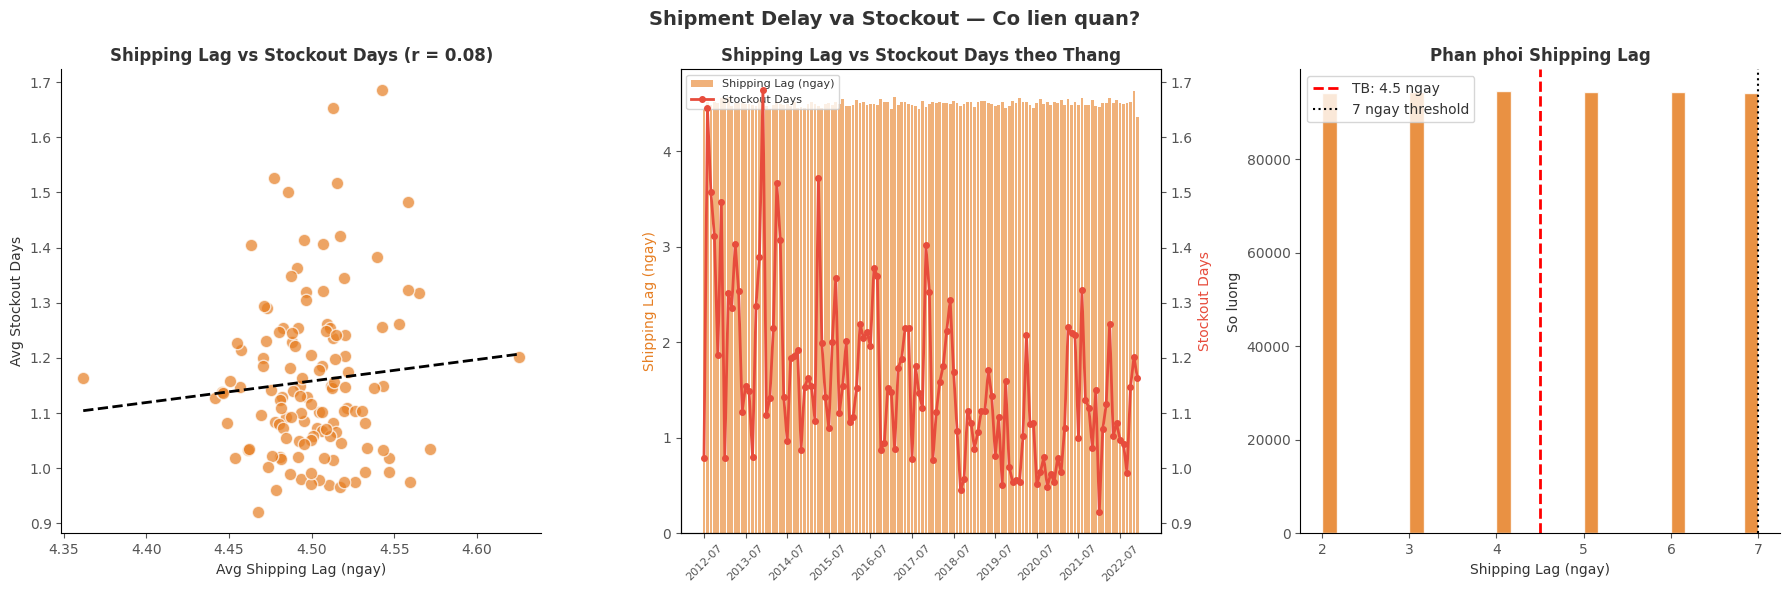

Don hang giao cham (> 7 ngay): 0 / 566,067 (0.0%)
Shipping lag TB               : 4.5 ngay
Shipping lag max              : 7 ngay


In [102]:
# ============================================================
# TIER 2 - #6: SHIPMENT DELAY LÀM STOCKOUT KÉO DÀI KHÔNG?
# shipping_lag = delivery_date - ship_date
# ============================================================

shipments["ship_date"]     = pd.to_datetime(shipments["ship_date"],     errors="coerce")
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"], errors="coerce")
shipments["shipping_lag"]  = (shipments["delivery_date"] - shipments["ship_date"]).dt.days
shipments["month"]         = shipments["ship_date"].dt.to_period("M")

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["month"]         = inventory["snapshot_date"].dt.to_period("M")

monthly_ship = shipments.groupby("month").agg(
    avg_shipping_lag = ("shipping_lag", "mean"),
    n_shipments      = ("order_id",     "count"),
).reset_index()

monthly_inv = inventory.groupby("month").agg(
    avg_stockout_days = ("stockout_days", "mean"),
    pct_stockout      = ("stockout_flag", "mean"),
).reset_index()

monthly = monthly_ship.merge(monthly_inv, on="month", how="inner")
monthly["month_str"] = monthly["month"].astype(str)

corr = monthly["avg_shipping_lag"].corr(monthly["avg_stockout_days"])
print(f"=== TUONG QUAN: Shipping Lag vs Stockout Days ===")
print(f"Pearson correlation: {corr:.3f}")
print(f"Nhan xet: {'Tuong quan duong manh' if corr > 0.5 else 'Tuong quan yeu' if corr > 0.2 else 'Khong ro tuong quan'}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Shipment Delay va Stockout — Co lien quan?", fontsize=14, fontweight="bold")

# Chart 1: Scatter shipping lag vs stockout days
ax = axes[0]
ax.scatter(monthly["avg_shipping_lag"], monthly["avg_stockout_days"],
           s=80, color="#E67E22", alpha=0.7, edgecolors="white")
z = np.polyfit(monthly["avg_shipping_lag"].fillna(0), monthly["avg_stockout_days"].fillna(0), 1)
p = np.poly1d(z)
xline = np.linspace(monthly["avg_shipping_lag"].min(), monthly["avg_shipping_lag"].max(), 100)
ax.plot(xline, p(xline), color="black", linewidth=2, linestyle="--")
ax.set_title(f"Shipping Lag vs Stockout Days (r = {corr:.2f})", fontweight="bold")
ax.set_xlabel("Avg Shipping Lag (ngay)")
ax.set_ylabel("Avg Stockout Days")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Xu hướng shipping lag theo tháng
ax = axes[1]
ax2 = ax.twinx()
step = max(1, len(monthly) // 10)
ax.bar(range(len(monthly)), monthly["avg_shipping_lag"],
       color="#E67E22", alpha=0.6, label="Shipping Lag (ngay)")
ax2.plot(range(len(monthly)), monthly["avg_stockout_days"],
         color="#E74C3C", linewidth=2, marker="o", markersize=4, label="Stockout Days")
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=8)
ax.set_title("Shipping Lag vs Stockout Days theo Thang", fontweight="bold")
ax.set_ylabel("Shipping Lag (ngay)", color="#E67E22")
ax2.set_ylabel("Stockout Days", color="#E74C3C")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)

# Chart 3: Phân phối shipping lag
ax = axes[2]
ax.hist(shipments["shipping_lag"].dropna(), bins=30, color="#E67E22", edgecolor="white", alpha=0.85)
ax.axvline(shipments["shipping_lag"].mean(), color="red", linewidth=2,
           linestyle="--", label=f"TB: {shipments['shipping_lag'].mean():.1f} ngay")
ax.axvline(7, color="black", linewidth=1.5, linestyle=":", label="7 ngay threshold")
ax.set_title("Phan phoi Shipping Lag", fontweight="bold")
ax.set_xlabel("Shipping Lag (ngay)")
ax.set_ylabel("So luong")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

slow_ship = shipments[shipments["shipping_lag"] > 7]
print(f"Don hang giao cham (> 7 ngay): {len(slow_ship):,} / {len(shipments):,} ({len(slow_ship)/len(shipments)*100:.1f}%)")
print(f"Shipping lag TB               : {shipments['shipping_lag'].mean():.1f} ngay")
print(f"Shipping lag max              : {shipments['shipping_lag'].max():.0f} ngay")


=== STOCKOUT ANH HUONG THEO AGE GROUP ===
           so_don_mat  doanh_thu_mat
age_group                           
25-34          141737   3.261111e+09
35-44          127487   2.911123e+09
45-54           92786   2.139685e+09
18-24           66579   1.520867e+09
55+             54183   1.238490e+09
=== STOCKOUT ANH HUONG THEO ACQUISITION CHANNEL ===
                     so_don_mat  doanh_thu_mat
acquisition_channel                           
organic_search           145002   3.332857e+09
social_media              96665   2.231967e+09
paid_search               96304   2.201557e+09
email_campaign            57884   1.322536e+09
referral                  48069   1.098804e+09
direct                    38848   8.835548e+08


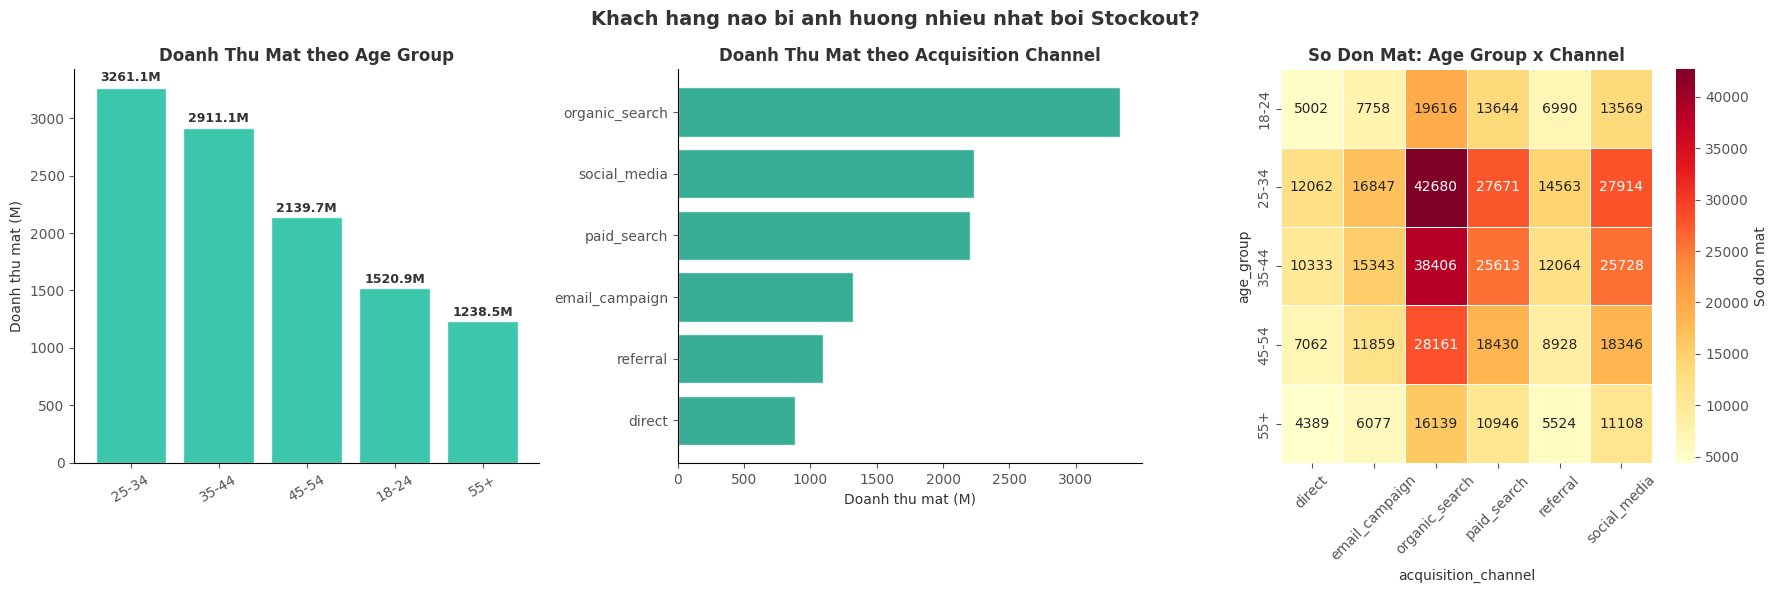

Age group bi thiet hai nhieu nhat    : 25-34 — 3,261,110,726
Channel bi thiet hai nhieu nhat      : organic_search — 3,332,856,775


In [103]:
# ============================================================
# TIER 2 - #8: KHÁCH HÀNG NÀO BỊ ẢNH HƯỞNG NHIỀU NHẤT BỞI STOCKOUT?
# age_group / acquisition_channel nào mất đơn vì hết hàng?
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

inventory   = pd.read_csv("inventory.csv")
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
customers   = pd.read_csv("customers.csv")
for d in [inventory, order_items, orders, customers]:
    d.columns = d.columns.str.lower().str.strip().str.replace(" ", "_")

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["month"]      = orders["order_date"].dt.to_period("M")
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")
inventory["month"]         = inventory["snapshot_date"].dt.to_period("M")

stockout = inventory[inventory["stockout_flag"] == 1][["product_id","month","stockout_days"]].drop_duplicates()

oi = order_items.merge(orders[["order_id","month","customer_id"]], on="order_id", how="left")
oi = oi.merge(customers[["customer_id","age_group","acquisition_channel","gender"]], on="customer_id", how="left")
oi["revenue"] = oi["quantity"] * oi["unit_price"]

affected = oi.merge(stockout, on=["product_id","month"], how="inner")

# Theo age_group
age_impact = affected.groupby("age_group").agg(
    so_don_mat    = ("order_id",   "count"),
    doanh_thu_mat = ("revenue",    "sum"),
).sort_values("doanh_thu_mat", ascending=False).round(0)

# Theo acquisition_channel
channel_impact = affected.groupby("acquisition_channel").agg(
    so_don_mat    = ("order_id",   "count"),
    doanh_thu_mat = ("revenue",    "sum"),
).sort_values("doanh_thu_mat", ascending=False).round(0)

print("=== STOCKOUT ANH HUONG THEO AGE GROUP ===")
print(age_impact.to_string())
print("=== STOCKOUT ANH HUONG THEO ACQUISITION CHANNEL ===")
print(channel_impact.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Khach hang nao bi anh huong nhieu nhat boi Stockout?",
             fontsize=14, fontweight="bold")

# Chart 1: Doanh thu mất theo age_group
ax = axes[0]
bars = ax.bar(age_impact.index.astype(str), age_impact["doanh_thu_mat"] / 1e6,
              color="#1ABC9C", edgecolor="white", alpha=0.85)
ax.set_title("Doanh Thu Mat theo Age Group", fontweight="bold")
ax.set_ylabel("Doanh thu mat (M)")
ax.tick_params(axis="x", rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{bar.get_height():.1f}M", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Doanh thu mất theo acquisition channel
ax = axes[1]
bars = ax.barh(channel_impact.index.astype(str), channel_impact["doanh_thu_mat"] / 1e6,
               color="#16A085", edgecolor="white", alpha=0.85)
ax.set_title("Doanh Thu Mat theo Acquisition Channel", fontweight="bold")
ax.set_xlabel("Doanh thu mat (M)")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 3: So đơn mất theo age_group + channel (heatmap)
ax = axes[2]
heat_data = affected.groupby(["age_group","acquisition_channel"])["order_id"].count().unstack(fill_value=0)
import seaborn as sns
sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "So don mat"})
ax.set_title("So Don Mat: Age Group x Channel", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Age group bi thiet hai nhieu nhat    : {age_impact.index[0]} — {age_impact['doanh_thu_mat'].iloc[0]:,.0f}")
print(f"Channel bi thiet hai nhieu nhat      : {channel_impact.index[0]} — {channel_impact['doanh_thu_mat'].iloc[0]:,.0f}")


Tuong quan Stockout Days vs Rating  : r = -0.095
Tuong quan Shipping Lag vs Rating   : r = 0.050


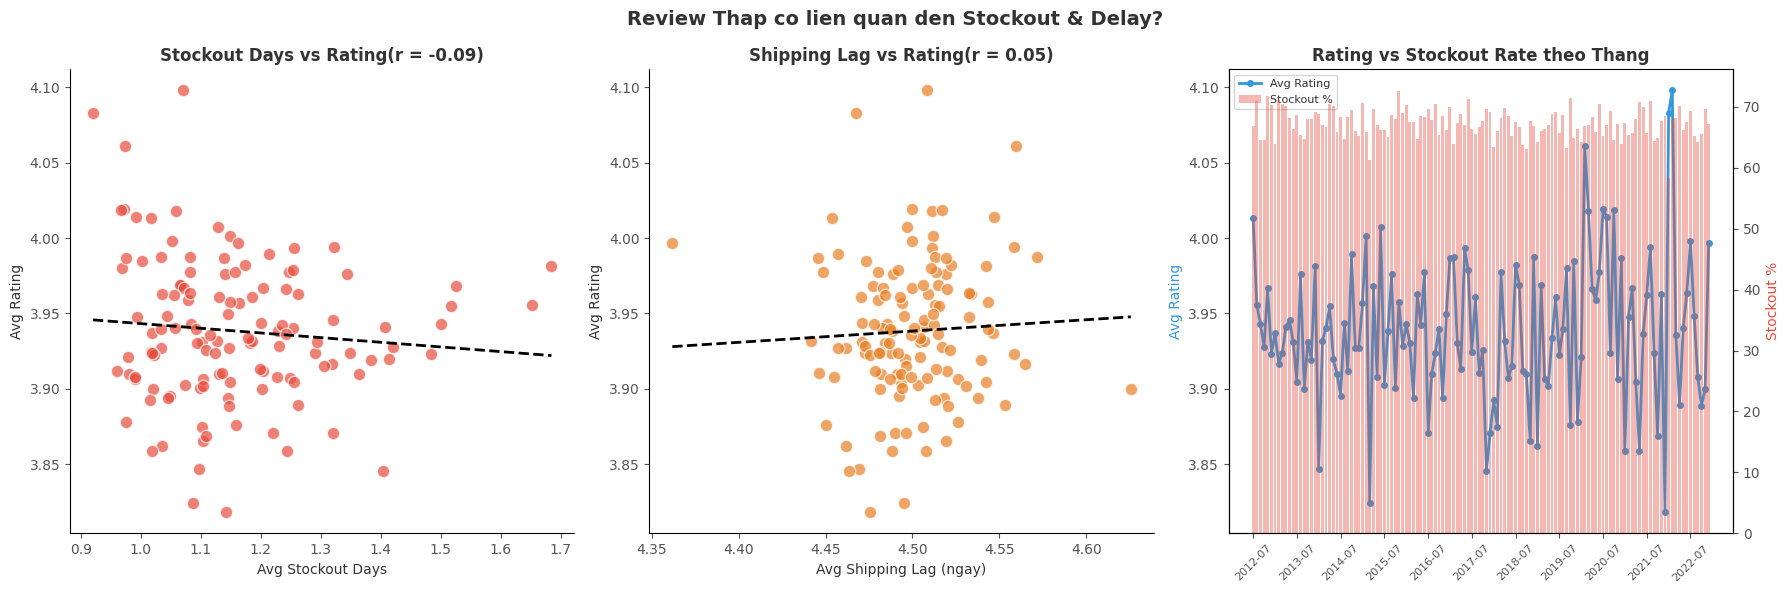

In [104]:
# ============================================================
# TIER 3 - #9: REVIEW THẤP CÓ LIÊN QUAN ĐẾN STOCKOUT/DELAY?
# Tháng stockout_days cao hoặc ship chậm → rating giảm?
# ============================================================

inventory = pd.read_csv("inventory.csv")
reviews   = pd.read_csv("reviews.csv")
shipments = pd.read_csv("shipments.csv")
for d in [inventory, reviews, shipments]:
    d.columns = d.columns.str.lower().str.strip().str.replace(" ", "_")

reviews["review_date"]     = pd.to_datetime(reviews["review_date"],    errors="coerce")
reviews["rating"]          = pd.to_numeric(reviews["rating"],          errors="coerce")
reviews["month"]           = reviews["review_date"].dt.to_period("M")
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"],errors="coerce")
inventory["month"]         = inventory["snapshot_date"].dt.to_period("M")
shipments["ship_date"]     = pd.to_datetime(shipments["ship_date"],    errors="coerce")
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"],errors="coerce")
shipments["shipping_lag"]  = (shipments["delivery_date"] - shipments["ship_date"]).dt.days
shipments["month"]         = shipments["ship_date"].dt.to_period("M")

monthly_rev  = reviews.groupby("month")["rating"].mean().reset_index(name="avg_rating")
monthly_inv  = inventory.groupby("month").agg(
    avg_stockout_days = ("stockout_days", "mean"),
    pct_stockout      = ("stockout_flag", "mean"),
).reset_index()
monthly_ship = shipments.groupby("month")["shipping_lag"].mean().reset_index(name="avg_shipping_lag")

monthly = monthly_rev.merge(monthly_inv, on="month", how="inner").merge(monthly_ship, on="month", how="left")
monthly["month_str"] = monthly["month"].astype(str)

corr_stockout = monthly["avg_stockout_days"].corr(monthly["avg_rating"])
corr_lag      = monthly["avg_shipping_lag"].corr(monthly["avg_rating"])
print(f"Tuong quan Stockout Days vs Rating  : r = {corr_stockout:.3f}")
print(f"Tuong quan Shipping Lag vs Rating   : r = {corr_lag:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Review Thap co lien quan den Stockout & Delay?", fontsize=14, fontweight="bold")

# Chart 1: Scatter stockout_days vs rating
ax = axes[0]
ax.scatter(monthly["avg_stockout_days"], monthly["avg_rating"],
           s=80, color="#E74C3C", alpha=0.7, edgecolors="white")
z = np.polyfit(monthly["avg_stockout_days"].fillna(0), monthly["avg_rating"].fillna(0), 1)
p = np.poly1d(z)
xline = np.linspace(monthly["avg_stockout_days"].min(), monthly["avg_stockout_days"].max(), 100)
ax.plot(xline, p(xline), color="black", linewidth=2, linestyle="--")
ax.set_title(f"Stockout Days vs Rating(r = {corr_stockout:.2f})", fontweight="bold")
ax.set_xlabel("Avg Stockout Days")
ax.set_ylabel("Avg Rating")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: Scatter shipping_lag vs rating
ax = axes[1]
ax.scatter(monthly["avg_shipping_lag"], monthly["avg_rating"],
           s=80, color="#E67E22", alpha=0.7, edgecolors="white")
z2 = np.polyfit(monthly["avg_shipping_lag"].fillna(0), monthly["avg_rating"].fillna(0), 1)
p2 = np.poly1d(z2)
xline2 = np.linspace(monthly["avg_shipping_lag"].dropna().min(),
                     monthly["avg_shipping_lag"].dropna().max(), 100)
ax.plot(xline2, p2(xline2), color="black", linewidth=2, linestyle="--")
ax.set_title(f"Shipping Lag vs Rating(r = {corr_lag:.2f})", fontweight="bold")
ax.set_xlabel("Avg Shipping Lag (ngay)")
ax.set_ylabel("Avg Rating")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 3: Xu hướng rating + stockout
ax = axes[2]
ax2 = ax.twinx()
step = max(1, len(monthly) // 10)
ax.plot(range(len(monthly)), monthly["avg_rating"],
        color="#3498DB", linewidth=2, marker="o", markersize=4, label="Avg Rating")
ax2.bar(range(len(monthly)), monthly["pct_stockout"] * 100,
        color="#E74C3C", alpha=0.4, label="Stockout %")
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=8)
ax.set_title("Rating vs Stockout Rate theo Thang", fontweight="bold")
ax.set_ylabel("Avg Rating", color="#3498DB")
ax2.set_ylabel("Stockout %", color="#E74C3C")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()


=== STOCKOUT & OVERSTOCK THEO REGION ===
         total_revenue  avg_stockout  avg_overstock  n_orders
region                                                       
West      3.851035e+09         0.670          0.861    192034
Central   4.941908e+09         0.669          0.854    201342
East      7.637533e+09         0.669          0.856    321293


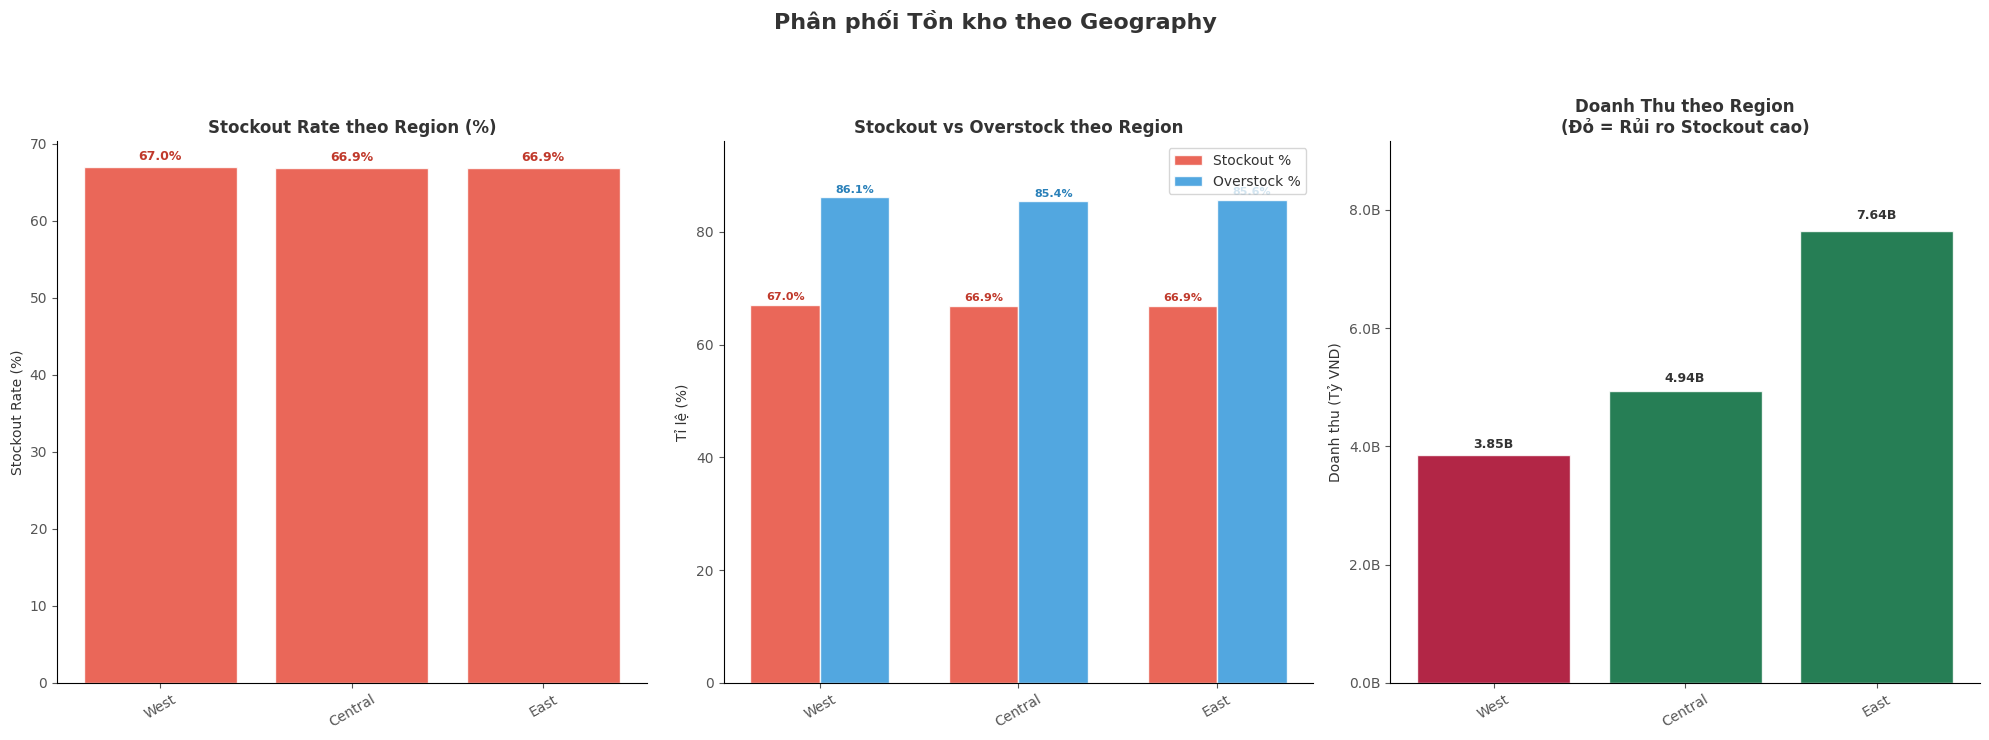

In [105]:
# TIER 3 - #10: INVENTORY THEO GEOGRAPHY
# Region nào stockout trong khi region khác overstock?

# Gắn geography vào orders
orders_geo = orders.merge(geography, on="zip", how="left")

# Gắn region vào order_items
oi = order_items.merge(orders_geo[["order_id","city","region"]], on="order_id", how="left")

# Tổng hợp stockout + overstock theo product + inventory (không có region nên dùng orders)
inv_agg = inventory.groupby("product_id").agg(
    pct_stockout  = ("stockout_flag",  "mean"),
    pct_overstock = ("overstock_flag", "mean"),
    avg_stock     = ("stock_on_hand",  "mean"),
).reset_index()

# Gắn inventory info vào order_items theo region
oi_inv = oi.merge(inv_agg, on="product_id", how="left")
oi_inv["revenue"] = oi_inv["quantity"] * oi_inv["unit_price"]

# Stockout theo region
region_stockout = oi_inv.groupby("region").agg(
    total_revenue   = ("revenue",       "sum"),
    avg_stockout    = ("pct_stockout",  "mean"),
    avg_overstock   = ("pct_overstock", "mean"),
    n_orders        = ("order_id",      "count"),
).round(3).sort_values("avg_stockout", ascending=False)

print("=== STOCKOUT & OVERSTOCK THEO REGION ===")
print(region_stockout.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Phân phối Tồn kho theo Geography", fontsize=16, fontweight="bold", y=1.05)

# --- Chart 1: Stockout rate theo region ---
ax = axes[0]
bars1 = ax.bar(region_stockout.index.astype(str),
               region_stockout["avg_stockout"] * 100,
               color="#E74C3C", edgecolor="white", alpha=0.85)
ax.set_title("Stockout Rate theo Region (%)", fontweight="bold")
ax.set_ylabel("Stockout Rate (%)")
ax.tick_params(axis="x", rotation=30)

# Thêm label cho Chart 1
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=9, color="#C0392B")

# --- Chart 2: Overstock vs Stockout rate per region (Grouped) ---
ax = axes[1]
x = np.arange(len(region_stockout))
width = 0.35

rects1 = ax.bar(x - width/2, region_stockout["avg_stockout"] * 100, width, 
                color="#E74C3C", label="Stockout %", edgecolor="white", alpha=0.85)
rects2 = ax.bar(x + width/2, region_stockout["avg_overstock"] * 100, width, 
                color="#3498DB", label="Overstock %", edgecolor="white", alpha=0.85)

# Hàm hỗ trợ gắn label cho biểu đồ cột nhóm
def add_grouped_labels(rects, color):
    for rect in rects:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.5,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold", color=color)

add_grouped_labels(rects1, "#C0392B")
add_grouped_labels(rects2, "#2980B9")

ax.set_xticks(x)
ax.set_xticklabels(region_stockout.index.astype(str), rotation=30)
ax.set_title("Stockout vs Overstock theo Region", fontweight="bold")
ax.set_ylabel("Tỉ lệ (%)")
ax.set_ylim(0, max(region_stockout["avg_overstock"].max(), region_stockout["avg_stockout"].max()) * 100 + 10)
ax.legend()

# Chart 3: Doanh thu theo region (có bị ảnh hưởng bởi stockout?)
ax = axes[2]
# Normalize màu sắc dựa trên stockout rate
norm = plt.Normalize(region_stockout["avg_stockout"].min(), region_stockout["avg_stockout"].max())
bar_colors = plt.cm.RdYlGn_r(norm(region_stockout["avg_stockout"].values))

bars3 = ax.bar(region_stockout.index.astype(str),
               region_stockout["total_revenue"] / 1e9,
               color=bar_colors, edgecolor="white", alpha=0.85)

ax.set_title("Doanh Thu theo Region\n(Đỏ = Rủi ro Stockout cao)", fontweight="bold")
ax.set_ylabel("Doanh thu (Tỷ VND)")
ax.tick_params(axis="x", rotation=30)

# Thêm label cho Chart 3
for bar in bars3:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (h * 0.02),
            f"{h:.2f}B", ha="center", va="bottom", fontweight="bold", fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}B"))
ax.set_ylim(0, (region_stockout["total_revenue"] / 1e9).max() * 1.2) # Nới trục Y để không mất label

# Tinh chỉnh chung cho cả 3 axes
for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

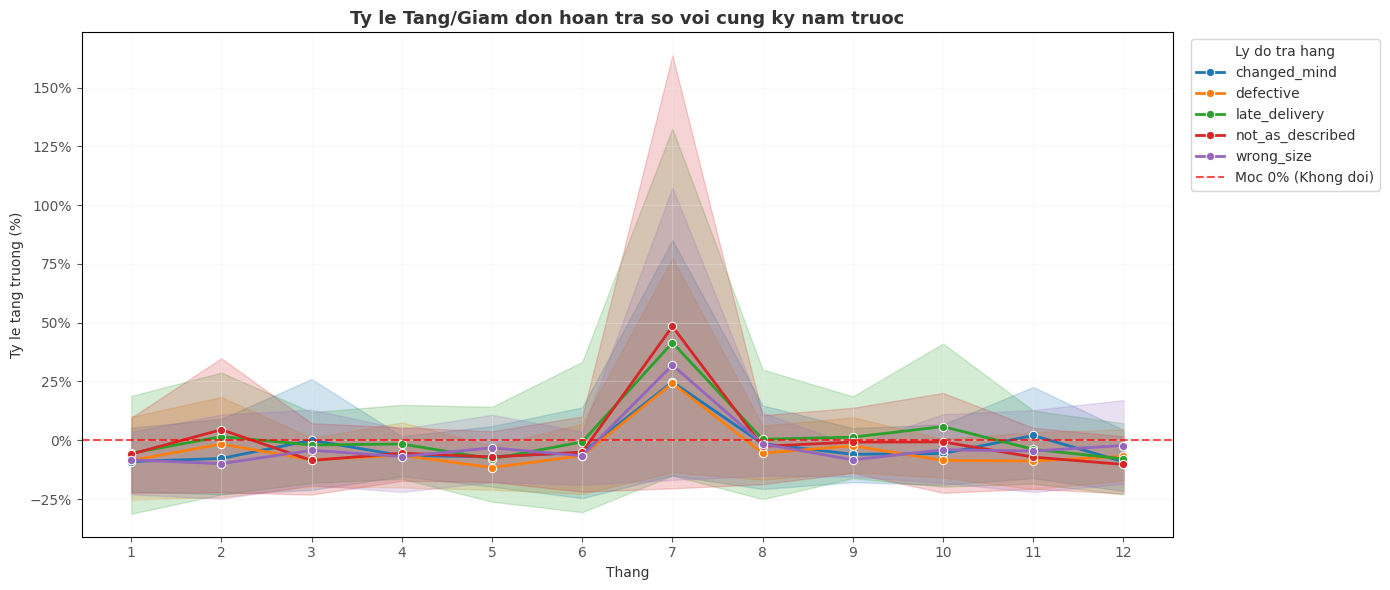


=== BANG TOM TAT GROWTH RATE THEO LY DO ===
                  TB (%)  Min (%)  Max (%)
return_reason                             
changed_mind        -2.4    -65.5    268.2
defective           -4.1    -61.3    251.9
late_delivery        2.0    -70.0    422.2
not_as_described     0.2    -66.0    526.7
wrong_size          -2.1    -56.7    358.8


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Đọc dữ liệu thực tế
returns   = pd.read_csv("returns.csv")
orders    = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")

returns.columns     = returns.columns.str.lower().str.strip()
orders.columns      = orders.columns.str.lower().str.strip()
order_items.columns = order_items.columns.str.lower().str.strip()

# 2. Gắn nhãn promo vào order_items
order_items["is_promo"] = (
    order_items["promo_id"].notna() &
    (~order_items["promo_id"].astype(str).str.strip().isin(["", "0", "nan"]))
)

# 3. Xử lý thời gian
returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")
returns["year"]  = returns["return_date"].dt.year
returns["month"] = returns["return_date"].dt.month

# 4. Gắn thông tin promo vào returns (qua order_id + product_id)
ret = returns.merge(
    order_items[["order_id", "product_id", "is_promo"]],
    on=["order_id", "product_id"],
    how="left"
)
ret["is_promo"] = ret["is_promo"].fillna(False)

# 5. Tổng hợp theo Năm, Tháng, Lý do trả hàng
agg_df = (ret
          .groupby(["year", "month", "return_reason"])
          .agg(return_qty=("return_id", "count"))
          .reset_index())

# 6. Tính dữ liệu năm trước (LY) bằng cách dịch year+1
agg_df_ly = agg_df.copy()
agg_df_ly["year"] = agg_df_ly["year"] + 1
agg_df_ly = agg_df_ly.rename(columns={"return_qty": "return_qty_ly"})

# 7. Merge năm nay với năm trước
final_df = pd.merge(agg_df, agg_df_ly,
                    on=["year", "month", "return_reason"],
                    how="left")

# 8. Tính growth rate YoY
final_df["growth_rate"] = (
    (final_df["return_qty"] - final_df["return_qty_ly"])
    / final_df["return_qty_ly"]
)

# Chỉ giữ các dòng có dữ liệu năm trước
plot_df = final_df.dropna(subset=["growth_rate"])

# 9. Lọc top 5 lý do trả hàng phổ biến nhất để biểu đồ không rối
top_reasons = (ret["return_reason"]
               .value_counts()
               .head(5)
               .index.tolist())
plot_df = plot_df[plot_df["return_reason"].isin(top_reasons)]

# 10. Vẽ biểu đồ
plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x="month", y="growth_rate",
             hue="return_reason", marker="o", linewidth=2)

plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="Moc 0% (Khong doi)")

plt.title("Ty le Tang/Giam don hoan tra so voi cung ky nam truoc",
          fontweight="bold", fontsize=13)
plt.xlabel("Thang")
plt.ylabel("Ty le tang truong (%)")
plt.xticks(range(1, 13))
plt.legend(title="Ly do tra hang", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

# 11. In bảng tóm tắt
print("\n=== BANG TOM TAT GROWTH RATE THEO LY DO ===")
summary = (plot_df
           .groupby("return_reason")["growth_rate"]
           .agg(["mean", "min", "max"])
           .mul(100)
           .round(1)
           .rename(columns={"mean": "TB (%)", "min": "Min (%)", "max": "Max (%)"}))
print(summary.to_string())

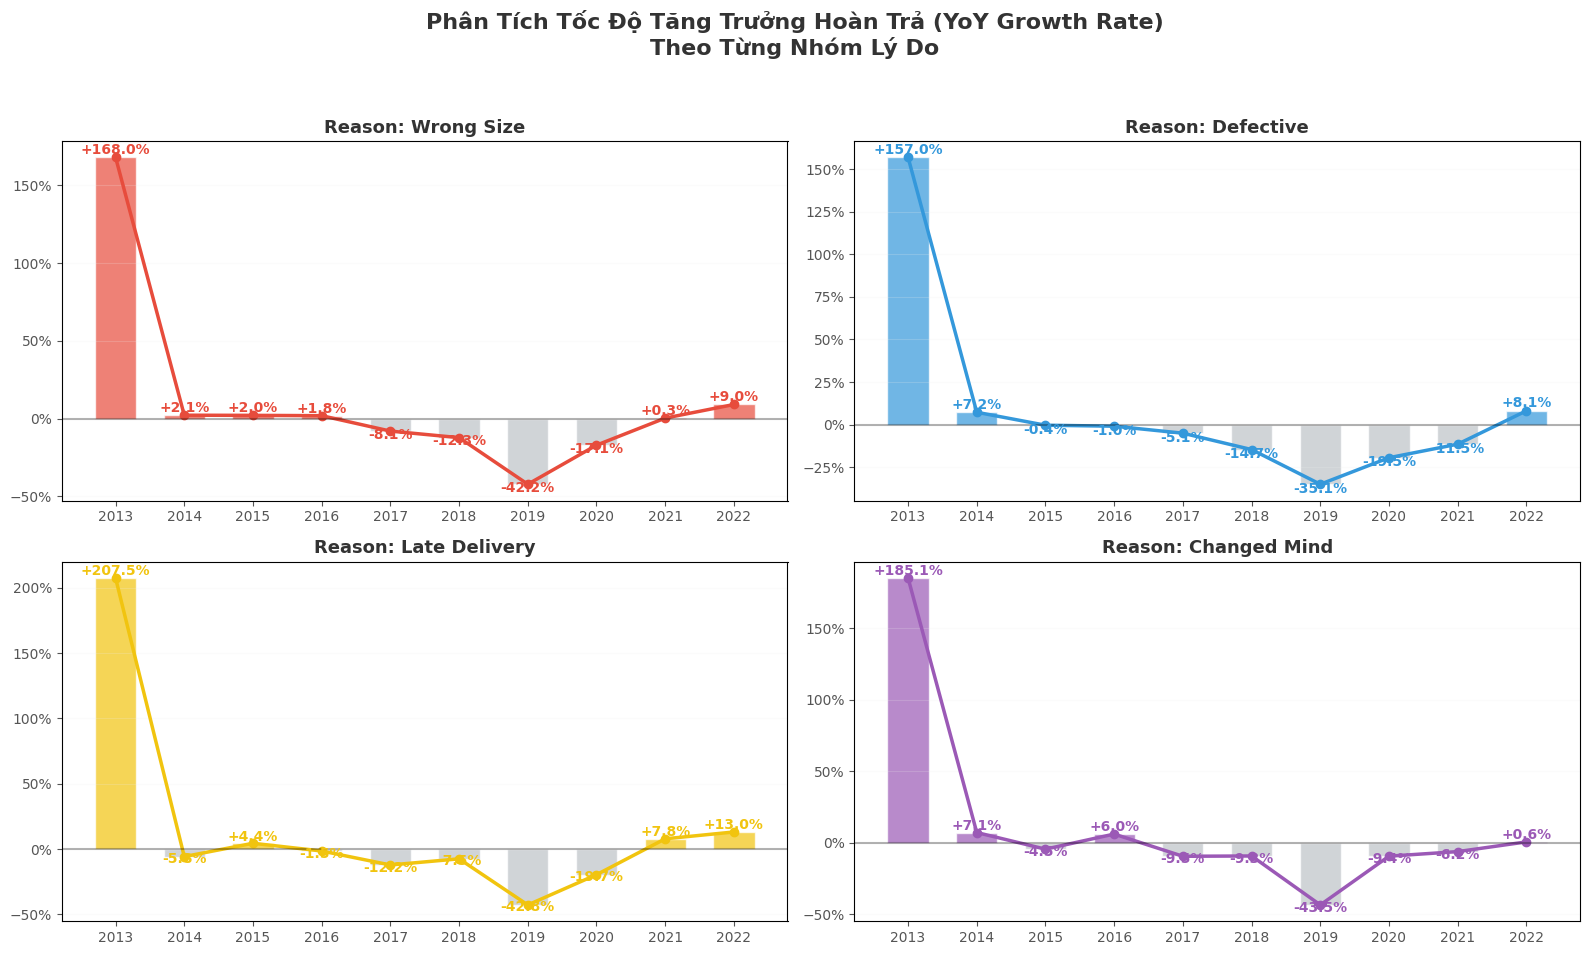

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Load và xử lý cơ bản
returns = pd.read_csv("returns.csv")
returns.columns = returns.columns.str.lower().str.strip()
returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")
returns["year"] = returns["return_date"].dt.year

# 2. Mở rộng danh sách lý do (Thêm late_delivery và changed_mind)
target_reasons = ["wrong_size", "defective", "late_delivery", "changed_mind"]
returns_filtered = returns[returns["return_reason"].isin(target_reasons)]

# 3. Tổng hợp YoY Growth (giữ nguyên logic của bạn)
agg_df = (returns_filtered
          .groupby(["year", "return_reason"])
          .agg(return_qty=("return_id", "count"))
          .reset_index())

agg_df_ly = agg_df.copy()
agg_df_ly["year"] = agg_df_ly["year"] + 1
agg_df_ly = agg_df_ly.rename(columns={"return_qty": "return_qty_ly"})

final_df = pd.merge(agg_df, agg_df_ly, on=["year","return_reason"], how="left")
final_df["growth_rate"] = (final_df["return_qty"] - final_df["return_qty_ly"]) / final_df["return_qty_ly"]
plot_df = final_df.dropna(subset=["growth_rate"])

# 4. Vẽ biểu đồ Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) # Đổi thành 2 hàng, 2 cột
fig.suptitle("Phân Tích Tốc Độ Tăng Trưởng Hoàn Trả (YoY Growth Rate)\nTheo Từng Nhóm Lý Do", 
             fontweight="bold", fontsize=16)

# Danh sách màu sắc cho từng loại lý do
colors_map = {
    "wrong_size": "#E74C3C",    # Đỏ (Sản phẩm/Size)
    "defective": "#3498DB",     # Xanh dương (Chất lượng)
    "late_delivery": "#F1C40F",  # Vàng (Vận hành)
    "changed_mind": "#9B59B6"    # Tím (Khách hàng)
}

axes_flat = axes.flatten()

for i, reason in enumerate(target_reasons):
    ax = axes_flat[i]
    sub = plot_df[plot_df["return_reason"] == reason]
    color = colors_map[reason]
    
    # Vẽ Bar + Line kết hợp
    ax.bar(sub["year"], sub["growth_rate"], 
           color=[color if v >= 0 else "#BDC3C7" for v in sub["growth_rate"]],
           edgecolor="white", alpha=0.7, width=0.6)
    ax.plot(sub["year"], sub["growth_rate"], color=color, marker="o", linewidth=2.5)
    
    # Định dạng
    ax.axhline(0, color="black", linestyle="-", alpha=0.3)
    ax.set_title(f"Reason: {reason.replace('_', ' ').title()}", fontweight="bold", fontsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xticks(sub["year"])
    ax.grid(True, axis='y', alpha=0.2)
    
    # Label giá trị %
    for x, y in zip(sub["year"], sub["growth_rate"]):
        ax.text(x, y + (0.02 if y >= 0 else -0.05), 
                f"{y*100:+.1f}%", ha="center", fontsize=10, fontweight="bold", color=color)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

=== A. RETURN RATE: Thang 7 vs Thang khac x Promo ===
promo_label Co Promo Khong Promo
july_label                      
Thang 7         3.06         3.3
Thang khac      3.06        3.07

=== B. GROSS PROFIT TRƯỚC vs SAU REFUND ===
                        avg_gross_profit  avg_net_gp  avg_refund  n_orders
july_label promo_label                                                    
Thang 7    Co Promo             -3621.17    -3995.23      374.06     38340
           Khong Promo           5066.78     4606.25      460.53     29463
Thang khac Co Promo             -2263.93    -2588.30      324.37    237976
           Khong Promo           5003.14     4574.56      428.58    408890


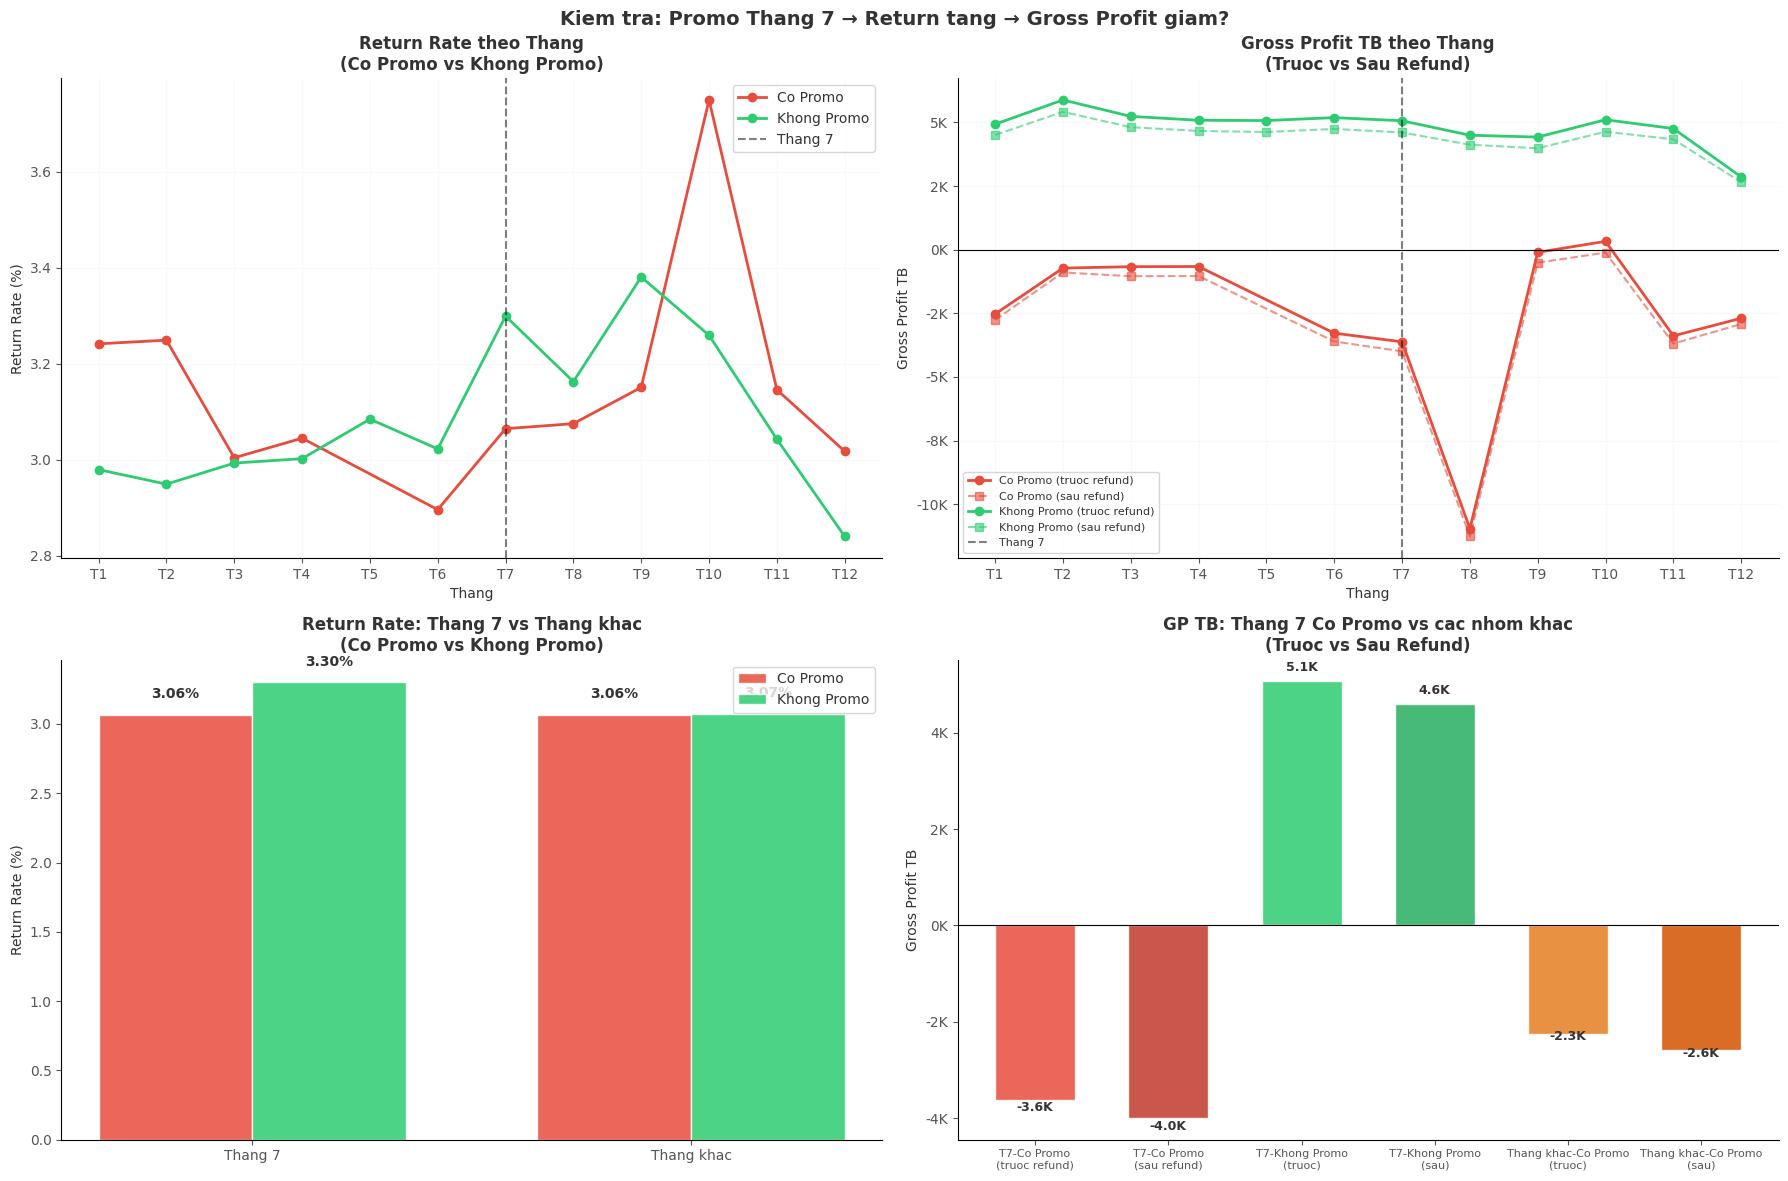


KET LUAN
Return rate T7 CO promo     : 3.06%
Return rate T7 KHONG promo  : 3.30%
Return rate T.khac CO promo : 3.06%

GP TB T7 Co Promo (truoc refund): -3,621
GP TB T7 Co Promo (sau refund) : -3,995
GP bi an mon boi refund T7     : 374

GP TB Thang khac Co Promo (truoc): -2,264
GP TB Thang khac Co Promo (sau) : -2,588

--- KIEM TRA 3 DIEU KIEN ---
[SAI] Return rate T7 Co Promo khong cao hon Khong Promo
[DUNG] Return rate T7 cao hon thang khac: 3.06% vs 3.06%
[DUNG] GP sau refund T7 thap hon thang khac: -3,995 vs -2,588


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# KIỂM TRA: PROMO THÁNG 7 → RETURN TĂNG → GROSS PROFIT GIẢM?
# ============================================================

# 1. Đọc dữ liệu
returns     = pd.read_csv("returns.csv")
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
products    = pd.read_csv("products.csv")

for d in [returns, order_items, orders, products]:
    d.columns = d.columns.str.lower().str.strip()

# 2. Xử lý thời gian
orders["order_date"]   = pd.to_datetime(orders["order_date"],   errors="coerce")
returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")
orders["month"]  = orders["order_date"].dt.month
orders["year"]   = orders["order_date"].dt.year
returns["month"] = returns["return_date"].dt.month
returns["year"]  = returns["return_date"].dt.year

# 3. Gắn nhãn promo
order_items["is_promo"] = (
    order_items["promo_id"].notna() &
    (~order_items["promo_id"].astype(str).str.strip().isin(["", "0", "nan"]))
)

# 4. Tính tài chính
cogs_map = products.set_index("product_id")["cogs"].to_dict()
qty   = order_items["quantity"].fillna(1)
price = order_items["unit_price"].fillna(0)
disc  = order_items["discount_amount"].fillna(0)

order_items["net_revenue"]  = qty * price - disc
order_items["cogs_val"]     = qty * order_items["product_id"].map(cogs_map).fillna(0)
order_items["gross_profit"] = order_items["net_revenue"] - order_items["cogs_val"]

# 5. Gắn month/year vào order_items
oi = order_items.merge(orders[["order_id","month","year"]], on="order_id", how="left")

# 6. Gắn thông tin return vào order_items
ret_flag = (returns[returns["return_reason"].isin(["wrong_size","defective"])]
            .groupby(["order_id","product_id"])
            .agg(return_qty=("return_quantity","sum"),
                 refund_amt=("refund_amount","sum"))
            .reset_index())
ret_flag["was_returned"] = True

oi = oi.merge(ret_flag, on=["order_id","product_id"], how="left")
oi["was_returned"]  = oi["was_returned"].fillna(False)
oi["return_qty"]    = oi["return_qty"].fillna(0)
oi["refund_amt"]    = oi["refund_amt"].fillna(0)
oi["net_gp"]        = oi["gross_profit"] - oi["refund_amt"]  # GP sau khi trừ refund
oi["is_july"]       = oi["month"] == 7
oi["promo_label"]   = oi["is_promo"].map({True: "Co Promo", False: "Khong Promo"})
oi["july_label"]    = oi["is_july"].map({True: "Thang 7", False: "Thang khac"})

# ============================================================
# PHÂN TÍCH
# ============================================================

# A. Return rate tháng 7 vs tháng khác, theo promo
return_rate = (oi.groupby(["july_label","promo_label"])["was_returned"]
               .mean().mul(100).round(2)
               .reset_index(name="return_rate_%"))
print("=== A. RETURN RATE: Thang 7 vs Thang khac x Promo ===")
print(return_rate.pivot(index="july_label", columns="promo_label", values="return_rate_%").to_string())

# B. Gross profit trước và sau refund: tháng 7 có promo
gp_compare = (oi.groupby(["july_label","promo_label"])
               .agg(
                   avg_gross_profit = ("gross_profit", "mean"),
                   avg_net_gp       = ("net_gp",       "mean"),
                   avg_refund       = ("refund_amt",   "mean"),
                   n_orders         = ("order_id",     "count"),
               ).round(2))
print("\n=== B. GROSS PROFIT TRƯỚC vs SAU REFUND ===")
print(gp_compare.to_string())

# C. So sánh theo từng tháng: return rate + gross profit
monthly = (oi.groupby(["month","promo_label"])
            .agg(
                return_rate  = ("was_returned",  "mean"),
                avg_gp       = ("gross_profit",  "mean"),
                avg_net_gp   = ("net_gp",        "mean"),
                avg_refund   = ("refund_amt",    "mean"),
            ).reset_index())

# ============================================================
# BIỂU ĐỒ
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Kiem tra: Promo Thang 7 → Return tang → Gross Profit giam?",
             fontsize=14, fontweight="bold")

colors = {"Co Promo": "#E74C3C", "Khong Promo": "#2ECC71"}

# --- Chart 1: Return rate theo tháng (Co Promo vs Khong Promo) ---
ax = axes[0, 0]
for label, color in colors.items():
    sub = monthly[monthly["promo_label"] == label]
    ax.plot(sub["month"], sub["return_rate"] * 100,
            marker="o", color=color, linewidth=2, label=label)
ax.axvline(7, color="black", linestyle="--", alpha=0.5, label="Thang 7")
ax.set_title("Return Rate theo Thang\n(Co Promo vs Khong Promo)", fontweight="bold")
ax.set_xlabel("Thang")
ax.set_ylabel("Return Rate (%)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f"T{i}" for i in range(1, 13)])
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Chart 2: Gross Profit TB theo tháng ---
ax = axes[0, 1]
for label, color in colors.items():
    sub = monthly[monthly["promo_label"] == label]
    ax.plot(sub["month"], sub["avg_gp"],
            marker="o", color=color, linewidth=2, label=f"{label} (truoc refund)")
    ax.plot(sub["month"], sub["avg_net_gp"],
            marker="s", color=color, linewidth=1.5, linestyle="--",
            alpha=0.6, label=f"{label} (sau refund)")
ax.axvline(7, color="black", linestyle="--", alpha=0.5, label="Thang 7")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Gross Profit TB theo Thang\n(Truoc vs Sau Refund)", fontweight="bold")
ax.set_xlabel("Thang")
ax.set_ylabel("Gross Profit TB")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f"T{i}" for i in range(1, 13)])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Chart 3: Bar — Return rate tháng 7 vs tháng khác x Promo ---
ax = axes[1, 0]
july_ret = (oi.groupby(["july_label","promo_label"])["was_returned"]
             .mean().mul(100).reset_index(name="return_rate_%"))
x     = [0, 1]
width = 0.35
promo_vals    = july_ret[july_ret["promo_label"] == "Co Promo"]["return_rate_%"].values
no_promo_vals = july_ret[july_ret["promo_label"] == "Khong Promo"]["return_rate_%"].values
labels_x      = july_ret[july_ret["promo_label"] == "Co Promo"]["july_label"].values

bars1 = ax.bar([i - width/2 for i in x], promo_vals,    width, color="#E74C3C",
               label="Co Promo",    edgecolor="white", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], no_promo_vals, width, color="#2ECC71",
               label="Khong Promo", edgecolor="white", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_title("Return Rate: Thang 7 vs Thang khac\n(Co Promo vs Khong Promo)", fontweight="bold")
ax.set_ylabel("Return Rate (%)")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}%", ha="center", va="bottom",
            fontweight="bold", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Chart 4: Bar — GP trước vs sau refund tháng 7 có promo ---
ax = axes[1, 1]
july_promo = oi[(oi["is_july"]) & (oi["is_promo"])]
july_non   = oi[(oi["is_july"]) & (~oi["is_promo"])]
other_promo = oi[(~oi["is_july"]) & (oi["is_promo"])]

compare_data = {
    "T7-Co Promo\n(truoc refund)":  july_promo["gross_profit"].mean(),
    "T7-Co Promo\n(sau refund)":    july_promo["net_gp"].mean(),
    "T7-Khong Promo\n(truoc)":      july_non["gross_profit"].mean(),
    "T7-Khong Promo\n(sau)":        july_non["net_gp"].mean(),
    "Thang khac-Co Promo\n(truoc)": other_promo["gross_profit"].mean(),
    "Thang khac-Co Promo\n(sau)":   other_promo["net_gp"].mean(),
}
bar_colors = ["#E74C3C","#C0392B","#2ECC71","#27AE60","#E67E22","#D35400"]
bars = ax.bar(compare_data.keys(), compare_data.values(),
              color=bar_colors, edgecolor="white", alpha=0.85, width=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("GP TB: Thang 7 Co Promo vs cac nhom khac\n(Truoc vs Sau Refund)", fontweight="bold")
ax.set_ylabel("Gross Profit TB")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.tick_params(axis="x", labelsize=8)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h * 1.03 if h >= 0 else h * 1.08,
            f"{h/1e3:.1f}K", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# KẾT LUẬN TỰ ĐỘNG
# ============================================================
print("\n" + "="*60)
print("KET LUAN")
print("="*60)

rr_july_promo  = oi[(oi["is_july"]) & (oi["is_promo"])]["was_returned"].mean() * 100
rr_july_non    = oi[(oi["is_july"]) & (~oi["is_promo"])]["was_returned"].mean() * 100
rr_other_promo = oi[(~oi["is_july"]) & (oi["is_promo"])]["was_returned"].mean() * 100

gp_july_promo_before  = oi[(oi["is_july"]) & (oi["is_promo"])]["gross_profit"].mean()
gp_july_promo_after   = oi[(oi["is_july"]) & (oi["is_promo"])]["net_gp"].mean()
gp_other_promo_before = oi[(~oi["is_july"]) & (oi["is_promo"])]["gross_profit"].mean()
gp_other_promo_after  = oi[(~oi["is_july"]) & (oi["is_promo"])]["net_gp"].mean()

print(f"Return rate T7 CO promo     : {rr_july_promo:.2f}%")
print(f"Return rate T7 KHONG promo  : {rr_july_non:.2f}%")
print(f"Return rate T.khac CO promo : {rr_other_promo:.2f}%")
print(f"\nGP TB T7 Co Promo (truoc refund): {gp_july_promo_before:,.0f}")
print(f"GP TB T7 Co Promo (sau refund) : {gp_july_promo_after:,.0f}")
print(f"GP bi an mon boi refund T7     : {gp_july_promo_before - gp_july_promo_after:,.0f}")
print(f"\nGP TB Thang khac Co Promo (truoc): {gp_other_promo_before:,.0f}")
print(f"GP TB Thang khac Co Promo (sau) : {gp_other_promo_after:,.0f}")

print("\n--- KIEM TRA 3 DIEU KIEN ---")
if rr_july_promo > rr_july_non:
    print(f"[DUNG] Promo T7 lam return rate cao hon: {rr_july_promo:.2f}% vs {rr_july_non:.2f}%")
else:
    print(f"[SAI] Return rate T7 Co Promo khong cao hon Khong Promo")

if rr_july_promo > rr_other_promo:
    print(f"[DUNG] Return rate T7 cao hon thang khac: {rr_july_promo:.2f}% vs {rr_other_promo:.2f}%")
else:
    print(f"[SAI] Return rate T7 khong cao hon thang khac")

if gp_july_promo_after < gp_other_promo_after:
    print(f"[DUNG] GP sau refund T7 thap hon thang khac: {gp_july_promo_after:,.0f} vs {gp_other_promo_after:,.0f}")
else:
    print(f"[SAI] GP sau refund T7 khong thap hon thang khac")

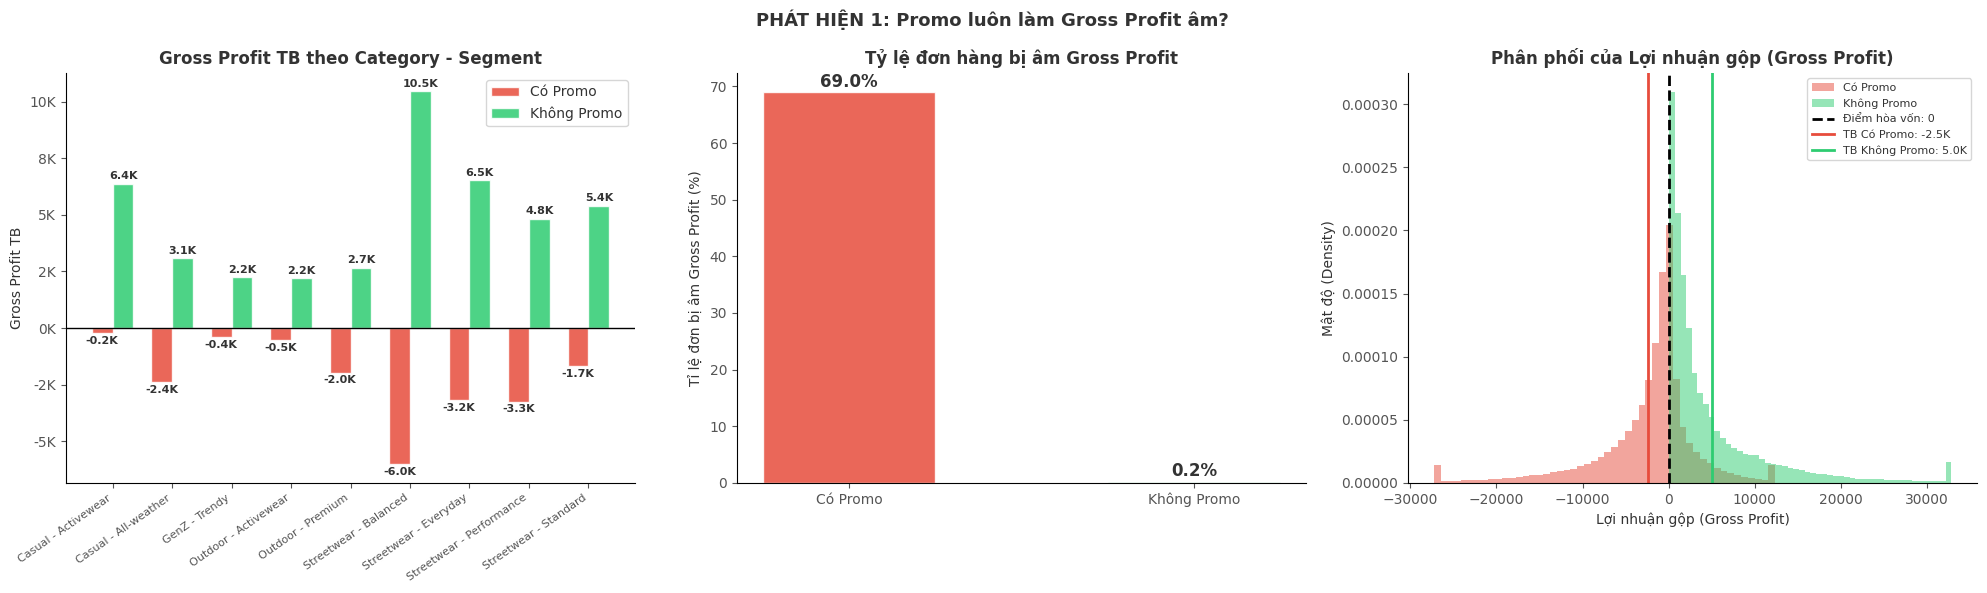

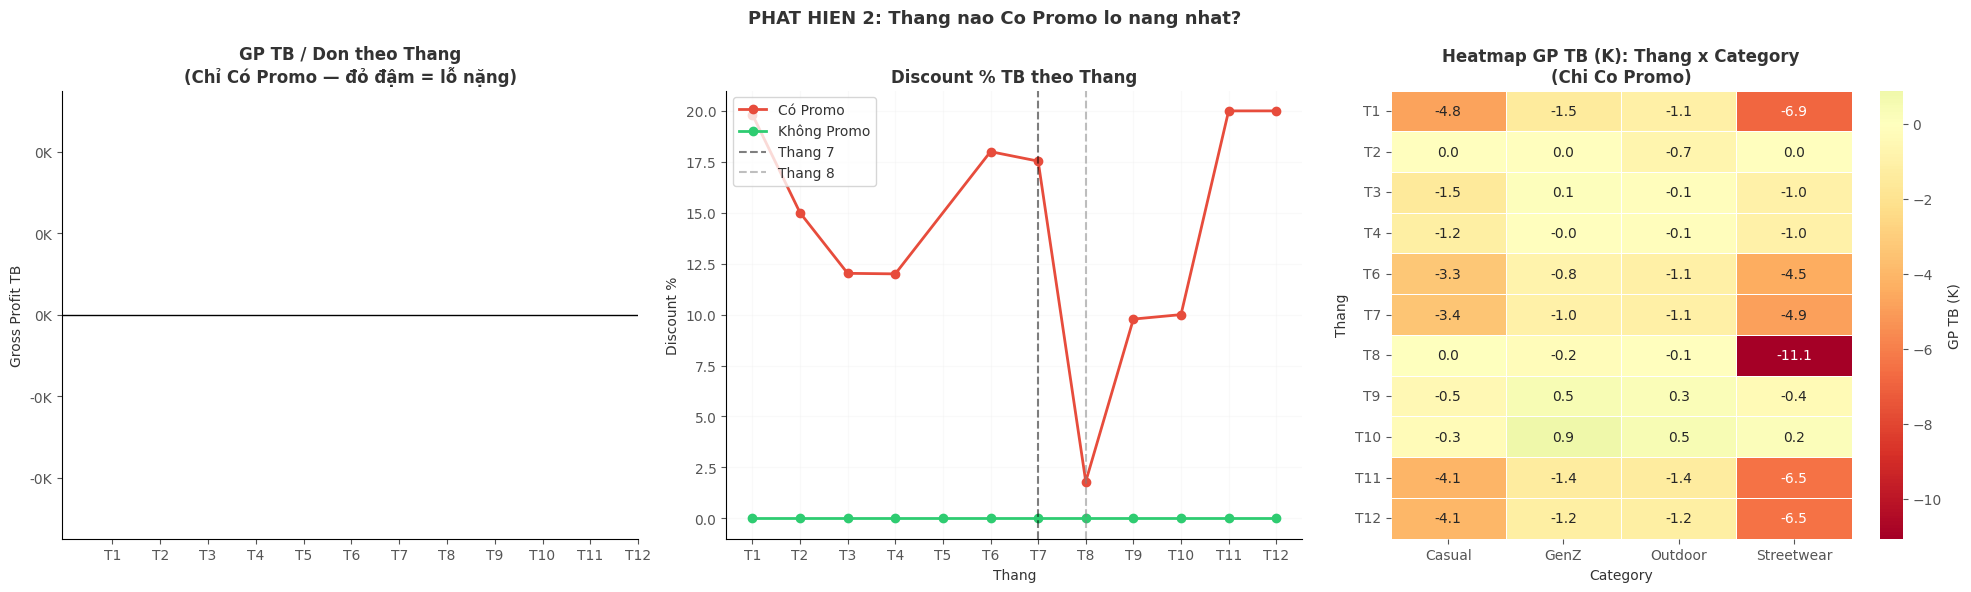

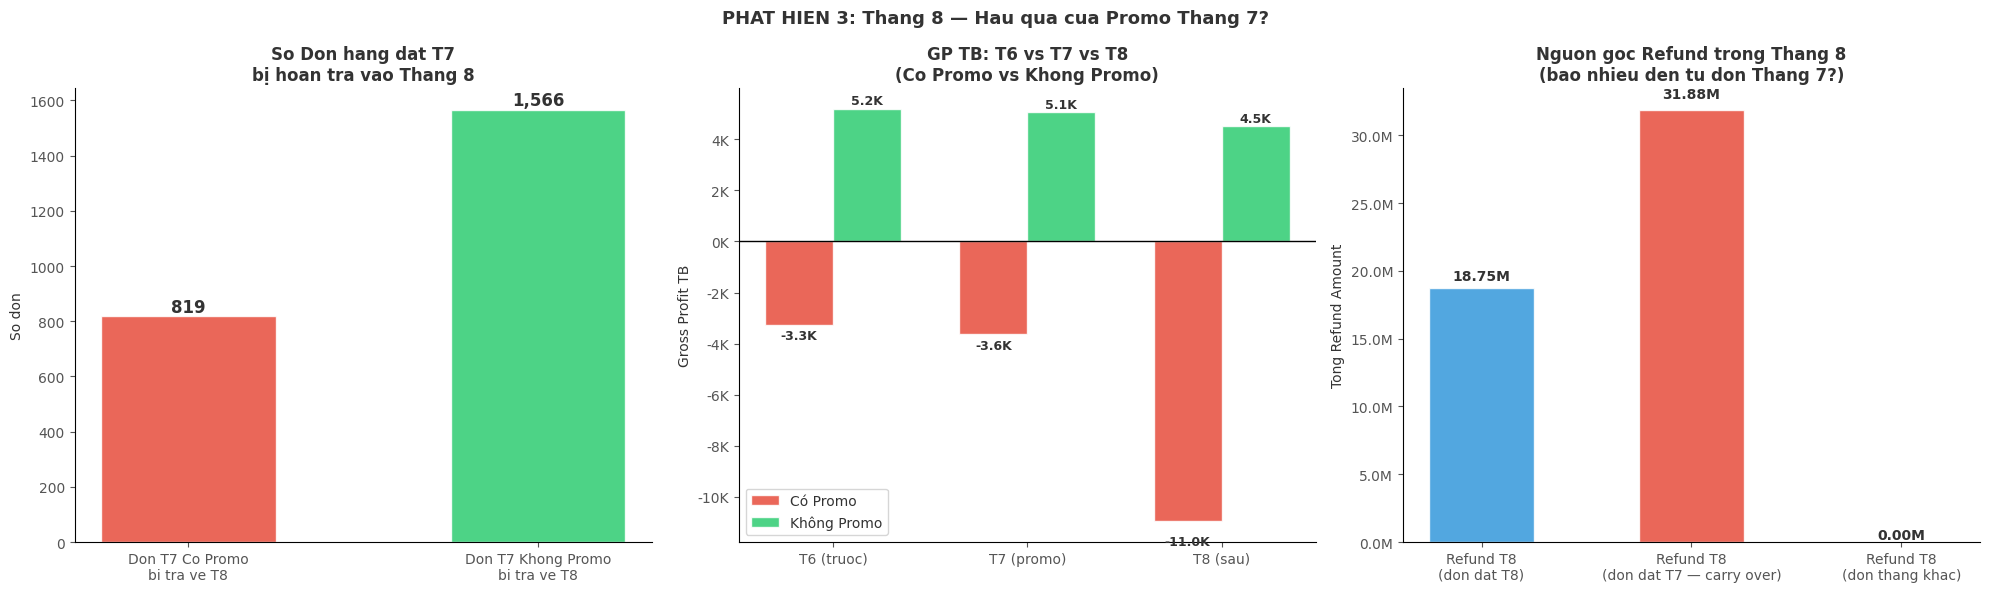


KET LUAN 3 PHAT HIEN


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# 1. Đọc dữ liệu
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
products    = pd.read_csv("products.csv")
returns     = pd.read_csv("returns.csv")

for d in [order_items, orders, products, returns]:
    d.columns = d.columns.str.lower().str.strip()

orders["order_date"]   = pd.to_datetime(orders["order_date"],   errors="coerce")
returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")
orders["month"] = orders["order_date"].dt.month
orders["year"]  = orders["order_date"].dt.year

# Tài chính
cogs_map = products.set_index("product_id")["cogs"].to_dict()
qty   = order_items["quantity"].fillna(1)
price = order_items["unit_price"].fillna(0)
disc  = order_items["discount_amount"].fillna(0)
order_items["net_revenue"]  = qty * price - disc
order_items["cogs_val"]     = qty * order_items["product_id"].map(cogs_map).fillna(0)
order_items["gross_profit"] = order_items["net_revenue"] - order_items["cogs_val"]
order_items["discount_pct"] = (disc / (qty * price).replace(0, np.nan) * 100).fillna(0)

# Promo
order_items["is_promo"] = (
    order_items["promo_id"].notna() &
    (~order_items["promo_id"].astype(str).str.strip().isin(["", "0", "nan"]))
)
order_items["promo_label"] = order_items["is_promo"].map({True: "Có Promo", False: "Không Promo"})

# Gắn month/year
oi = order_items.merge(orders[["order_id","month","year"]], on="order_id", how="left")
oi = oi.merge(products[["product_id","category","segment"]], on="product_id", how="left")

# Gắn refund
ret = (returns.groupby(["order_id","product_id"])
       .agg(refund_amt=("refund_amount","sum"))
       .reset_index())
oi = oi.merge(ret, on=["order_id","product_id"], how="left")
oi["refund_amt"] = oi["refund_amt"].fillna(0)
oi["net_gp"]     = oi["gross_profit"] - oi["refund_amt"]

colors = {"Có Promo": "#E74C3C", "Không Promo": "#2ECC71"}

# PHÁT HIỆN 1: Promo luôn âm GP 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("PHÁT HIỆN 1: Promo luôn làm Gross Profit âm?",
             fontsize=13, fontweight="bold")

# Chart 1: GP TB theo category x promo
ax = axes[0]
cat_seg_gp = (oi.groupby(["category", "segment", "promo_label"])["gross_profit"]
                .mean().reset_index())
cat_seg_gp["cat_seg"] = cat_seg_gp["category"].astype(str) + " - " + cat_seg_gp["segment"].astype(str)
cat_pivot = cat_seg_gp.pivot(index="cat_seg", columns="promo_label", values="gross_profit").fillna(0)
x = np.arange(len(cat_pivot))
width = 0.35
for i, (label, color) in enumerate(colors.items()):
    vals = cat_pivot.get(label, pd.Series([0]*len(cat_pivot))).values
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  color=color, label=label, edgecolor="white", alpha=0.85)
    for bar, val in zip(bars, vals):
        y = val + 120 if val >= 0 else val - 120
        ax.text(bar.get_x() + bar.get_width()/2, y,
                f"{val/1e3:.1f}K", ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=8, fontweight="bold")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(cat_pivot.index, rotation=35, ha="right", fontsize=8)
ax.set_title("Gross Profit TB theo Category - Segment", fontweight="bold")
ax.set_ylabel("Gross Profit TB")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 2: % sản phẩm âm GP khi có Promo vs Không Promo
ax = axes[1]
pct_neg = (oi.groupby("promo_label")
            .apply(lambda x: (x["gross_profit"] < 0).mean() * 100)
            .reset_index(name="pct_negative_gp"))
bars = ax.bar(pct_neg["promo_label"], pct_neg["pct_negative_gp"],
              color=[colors[l] for l in pct_neg["promo_label"]],
              width=0.5, edgecolor="white", alpha=0.85)
ax.set_title("Tỷ lệ đơn hàng bị âm Gross Profit", fontweight="bold")
ax.set_ylabel("Tỉ lệ đơn bị âm Gross Profit (%)")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chart 3: Phân phối GP: Có Promo vs Không Promo (histogram)
ax = axes[2]
for label, color in colors.items():
    sub = oi[oi["promo_label"] == label]["gross_profit"]
    # Clip dữ liệu để tránh các giá trị ngoại lai (outliers) quá xa làm loãng biểu đồ
    sub_clip = sub.clip(sub.quantile(0.01), sub.quantile(0.99))
    ax.hist(sub_clip, bins=50, alpha=0.5, color=color, label=label, density=True)

ax.axvline(0, color="black", linewidth=2, linestyle="--", label="Điểm hòa vốn: 0")

# Đường trung bình cho nhóm Có Promo
ax.axvline(oi[oi["is_promo"]]["gross_profit"].mean(),
           color="#E74C3C", linewidth=2, linestyle="-",
           label=f"TB Có Promo: {oi[oi['is_promo']]['gross_profit'].mean()/1e3:.1f}K")

# Đường trung bình cho nhóm Không Promo
ax.axvline(oi[~oi["is_promo"]]["gross_profit"].mean(),
           color="#2ECC71", linewidth=2, linestyle="-",
           label=f"TB Không Promo: {oi[~oi['is_promo']]['gross_profit'].mean()/1e3:.1f}K")

# Thiết lập tiêu đề và nhãn các trục
ax.set_title("Phân phối của Lợi nhuận gộp (Gross Profit)", fontweight="bold")
ax.set_xlabel("Lợi nhuận gộp (Gross Profit)")
ax.set_ylabel("Mật độ (Density)")  

ax.legend(fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# PHÁT HIỆN 2: Tháng nào có promo lỗ nặng nhất?
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("PHAT HIEN 2: Thang nao Co Promo lo nang nhat?",
             fontsize=13, fontweight="bold")

monthly = (oi.groupby(["month","promo_label"])
            .agg(
                avg_gp       = ("gross_profit",  "mean"),
                avg_net_gp   = ("net_gp",        "mean"),
                avg_disc_pct = ("discount_pct",  "mean"),
                total_gp     = ("gross_profit",  "sum"),
                n_orders     = ("order_id",      "count"),
            ).reset_index())

month_labels = [f"T{i}" for i in range(1, 13)]

# 2a. GP TB theo tháng — Co Promo
ax = axes[0]
promo_monthly = monthly[monthly["promo_label"] == "Co Promo"].sort_values("month")
bar_colors = ["#C0392B" if v < -3000 else "#E74C3C" if v < 0 else "#2ECC71"
              for v in promo_monthly["avg_gp"]]
bars = ax.bar(promo_monthly["month"], promo_monthly["avg_gp"],
              color=bar_colors, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("GP TB / Don theo Thang\n(Chỉ Có Promo — đỏ đậm = lỗ nặng)", fontweight="bold")
ax.set_ylabel("Gross Profit TB")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, val in zip(bars, promo_monthly["avg_gp"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            val * 1.05 if val < 0 else val + 100,
            f"{val/1e3:.1f}K", ha="center",
            va="top" if val < 0 else "bottom",
            fontweight="bold", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2b. Discount % theo tháng
ax = axes[1]
for label, color in colors.items():
    sub = monthly[monthly["promo_label"] == label].sort_values("month")
    ax.plot(sub["month"], sub["avg_disc_pct"],
            marker="o", color=color, linewidth=2, label=label)
ax.axvline(7, color="black", linestyle="--", alpha=0.5, label="Thang 7")
ax.axvline(8, color="gray",  linestyle="--", alpha=0.5, label="Thang 8")
ax.set_title("Discount % TB theo Thang", fontweight="bold")
ax.set_xlabel("Thang")
ax.set_ylabel("Discount %")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2c. Heatmap GP TB theo tháng x category (chỉ Co Promo)
ax = axes[2]
heat = (oi[oi["is_promo"]]
        .groupby(["month","category"])["gross_profit"]
        .mean().unstack(fill_value=0) / 1e3)
import seaborn as sns
sns.heatmap(heat, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "GP TB (K)"})
ax.set_title("Heatmap GP TB (K): Thang x Category\n(Chi Co Promo)", fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Thang")
ax.set_yticklabels([f"T{int(m)}" for m in heat.index], rotation=0)

plt.tight_layout()
plt.show()

# PHÁT HIỆN 3: Tháng 8 là hậu quả của promo tháng 7?
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("PHAT HIEN 3: Thang 8 — Hau qua cua Promo Thang 7?",
             fontsize=13, fontweight="bold")

# 3a. Đơn đặt T7 nhưng trả về T8 (return lag)
returns["return_month"] = returns["return_date"].dt.month
returns["return_year"]  = returns["return_date"].dt.year
oi_july = oi[oi["month"] == 7][["order_id","product_id","is_promo","gross_profit"]]
ret_aug  = returns[returns["return_month"] == 8]

july_returned_in_aug = ret_aug.merge(
    oi_july, on=["order_id","product_id"], how="inner"
)
ax = axes[0]
n_july_promo_ret_aug   = july_returned_in_aug[july_returned_in_aug["is_promo"]]["order_id"].count()
n_july_nopromo_ret_aug = july_returned_in_aug[~july_returned_in_aug["is_promo"]]["order_id"].count()
refund_july_promo_aug  = ret_aug.merge(
    oi_july[oi_july["is_promo"]], on=["order_id","product_id"], how="inner"
)["refund_amount"].sum()

bars = ax.bar(["Don T7 Co Promo\nbi tra ve T8",
               "Don T7 Khong Promo\nbi tra ve T8"],
              [n_july_promo_ret_aug, n_july_nopromo_ret_aug],
              color=["#E74C3C","#2ECC71"], width=0.5, edgecolor="white", alpha=0.85)
ax.set_title("So Don hang dat T7\nbị hoan tra vao Thang 8", fontweight="bold")
ax.set_ylabel("So don")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{int(bar.get_height()):,}", ha="center", va="bottom",
            fontweight="bold", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 3b. So sánh GP tháng 7 vs tháng 8 vs tháng 6 (baseline)
ax = axes[1]
months_focus = [6, 7, 8]
month_names  = {6: "T6 (truoc)", 7: "T7 (promo)", 8: "T8 (sau)"}
focus_data   = (oi[oi["month"].isin(months_focus)]
                .groupby(["month","promo_label"])
                .agg(avg_gp=("gross_profit","mean"),
                     avg_net_gp=("net_gp","mean"))
                .reset_index())

x     = np.arange(len(months_focus))
width = 0.35
for i, (label, color) in enumerate(colors.items()):
    sub  = focus_data[focus_data["promo_label"] == label].sort_values("month")
    vals = sub["avg_gp"].values
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  color=color, label=label, edgecolor="white", alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val * 1.05 if val < 0 else val + 50,
                f"{val/1e3:.1f}K", ha="center",
                va="top" if val < 0 else "bottom",
                fontweight="bold", fontsize=9)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([month_names[m] for m in months_focus])
ax.set_title("GP TB: T6 vs T7 vs T8\n(Co Promo vs Khong Promo)", fontweight="bold")
ax.set_ylabel("Gross Profit TB")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 3c. Return amount tháng 8 từ đơn T7 vs đơn T8 thuần
ax = axes[2]
# Đơn đặt T8 bị trả T8
oi_aug    = oi[oi["month"] == 8][["order_id","product_id","is_promo"]]
ret_aug8  = returns[returns["return_month"] == 8]
aug_from_aug = ret_aug8.merge(oi_aug,  on=["order_id","product_id"], how="inner")
aug_from_jul = ret_aug8.merge(oi_july, on=["order_id","product_id"], how="inner")

refund_from_aug = aug_from_aug["refund_amount"].sum()
refund_from_jul = aug_from_jul["refund_amount"].sum()
refund_other    = ret_aug8["refund_amount"].sum() - refund_from_aug - refund_from_jul

bars = ax.bar(["Refund T8\n(don dat T8)",
               "Refund T8\n(don dat T7 — carry over)",
               "Refund T8\n(don thang khac)"],
              [refund_from_aug, refund_from_jul, max(0, refund_other)],
              color=["#3498DB","#E74C3C","#95A5A6"],
              width=0.5, edgecolor="white", alpha=0.85)
ax.set_title("Nguon goc Refund trong Thang 8\n(bao nhieu den tu don Thang 7?)", fontweight="bold")
ax.set_ylabel("Tong Refund Amount")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
            f"{h/1e6:.2f}M", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# PRINT KẾT LUẬN
print("\n" + "="*60)
print("KET LUAN 3 PHAT HIEN")
print("="*60)

=== SCHEMA CHECK ===
inventory cols : ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
shipments cols : ['order_id', 'ship_date', 'delivery_date', 'shipping_fee']

=== 1. INVENTORY TURNOVER THEO CATEGORY ===
            avg_turnover  avg_days_supply  avg_sell_through
category                                                   
Streetwear        297.69           866.40              0.16
Outdoor           193.34          1085.45              0.14
GenZ               36.95           628.12              0.17
Casual             34.44           393.47              0.17

=== 2. LEAD-TIME ===
Lead-time TB    : 4.5 ngay
Lead-time Median: 4.0 ngay
Lead-time P90   : 7.0 ngay

Phân phối lead-time:
lead_time_group
4-7 ngay      66.7
≤3 ngay       33.3
8-14 ngay      0.0
15-21 ngay     0.0
>21 nga

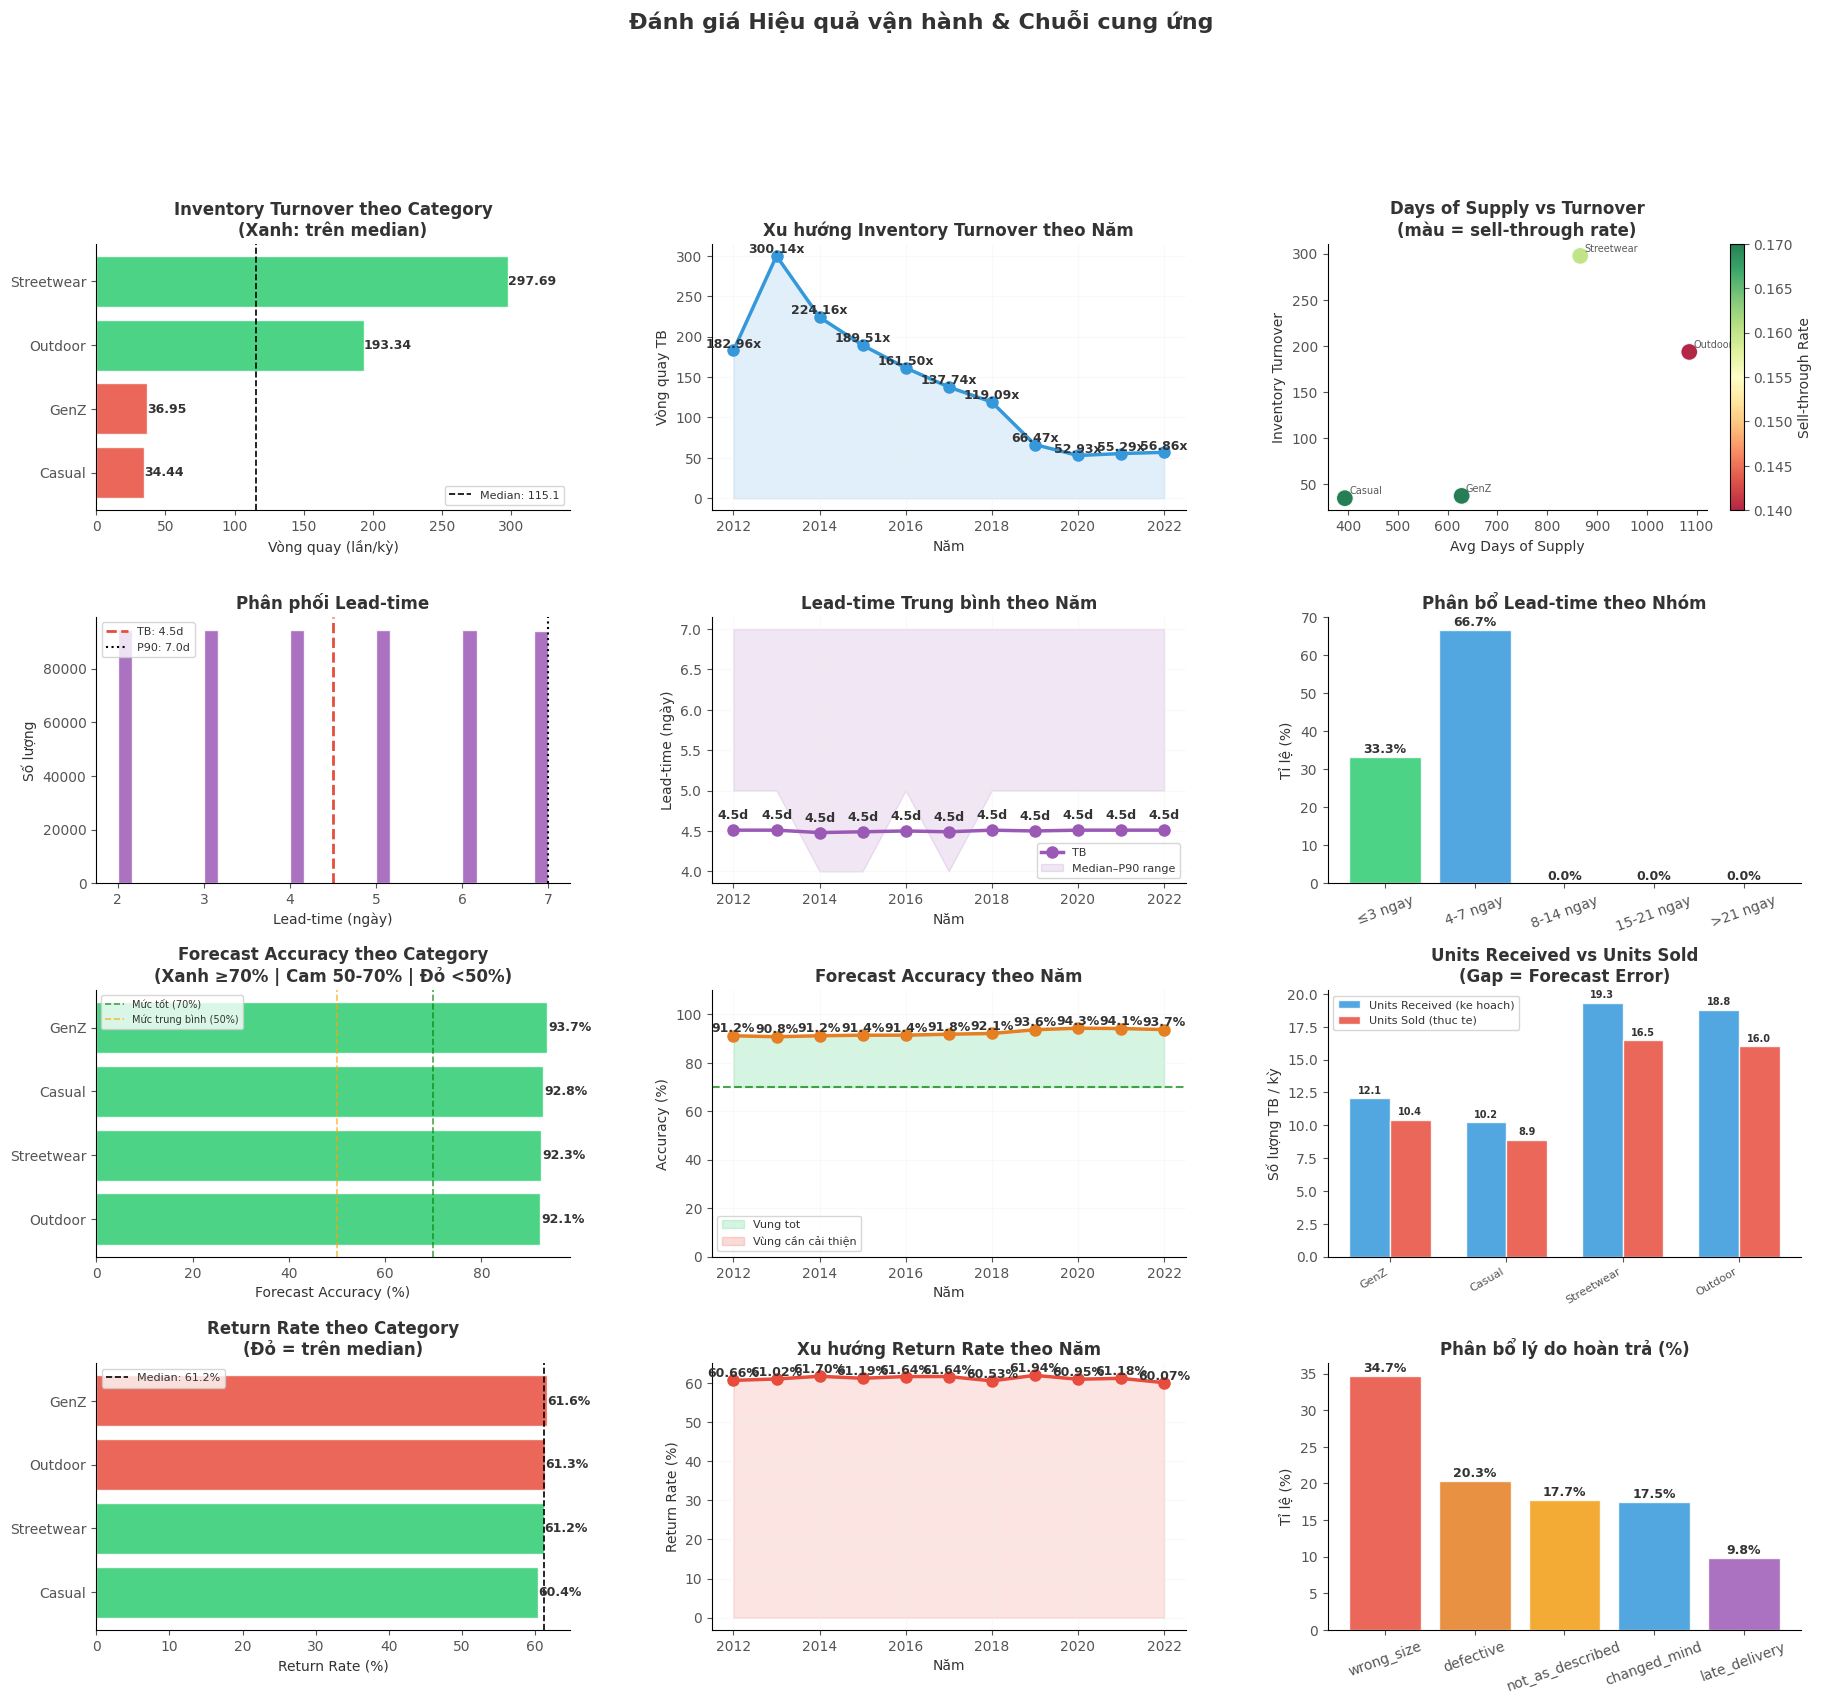


SCORECARD: HIEU QUA VAN HANH & CHUAN CUNG UNG

1. Inventory Turnover  : 140.61x  → TOT
2. Lead-time TB        : 4.5 ngay  → TOT
   % don lead > 14 ngay: 0.0%
3. Forecast Accuracy   : 92.4%  → TOT
4. Return Rate TB      : 61.12%  → KEM

Tieu chuan tham khao (nganh Thoi trang):
  Inventory Turnover : > 4x/ky = Tot | 2-4x = Trung binh | < 2x = Kem
  Lead-time          : < 7 ngay = Tot | 7-14 ngay = TB   | > 14 ngay = Kem
  Forecast Accuracy  : > 70%   = Tot | 50-70%    = TB   | < 50%     = Kem
  Return Rate        : < 5%    = Tot | 5-10%     = TB   | > 10%     = Kem



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# ĐÁNH GIÁ HIỆU QUẢ VẬN HÀNH & CHUỖI CUNG ỨNG
# 1. Inventory Turnover  — vòng quay hàng tồn kho
# 2. Lead-time           — thời gian đáp ứng
# 3. Forecast Accuracy   — độ chính xác dự báo
# 4. Return Rate         — tỷ lệ hoàn trả
# ============================================================

# --- Load dữ liệu ---
inventory   = pd.read_csv("inventory.csv")
shipments   = pd.read_csv("shipments.csv")
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
products    = pd.read_csv("products.csv")
returns     = pd.read_csv("returns.csv")

for d in [inventory, shipments, order_items, orders, products, returns]:
    d.columns = d.columns.str.lower().str.strip().str.replace(" ", "_")

print("=== SCHEMA CHECK ===")
print("inventory cols :", inventory.columns.tolist())
print("shipments cols :", shipments.columns.tolist())

# Chuẩn hóa thời gian
shipments["ship_date"]     = pd.to_datetime(shipments["ship_date"],     errors="coerce")
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"], errors="coerce")
orders["order_date"]       = pd.to_datetime(orders["order_date"],       errors="coerce")
returns["return_date"]     = pd.to_datetime(returns["return_date"],     errors="coerce")
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"], errors="coerce")

shipments["month"] = shipments["ship_date"].dt.to_period("M")
shipments["year"]  = shipments["ship_date"].dt.year
orders["month"]    = orders["order_date"].dt.to_period("M")
orders["year"]     = orders["order_date"].dt.year
inventory["month"] = inventory["snapshot_date"].dt.to_period("M")
inventory["year"]  = inventory["snapshot_date"].dt.year

# ============================================================
# 1. INVENTORY TURNOVER
# Công thức: units_sold / avg(stock_on_hand) — theo tháng/năm/category
# avg_stock_on_hand = (stock_on_hand đầu tháng + stock_on_hand cuối tháng) / 2
# stock_on_hand đầu tháng = stock_on_hand cuối tháng trước
# ============================================================

# Sắp xếp để đảm bảo thứ tự đúng trước khi shift
inventory = inventory.sort_values(["category", "year", "month"]).reset_index(drop=True)

# Tính stock_on_hand đầu tháng = stock_on_hand cuối tháng trước (trong cùng category)
inventory["stock_begin"] = inventory.groupby("category")["stock_on_hand"].shift(1)

# avg_stock_on_hand theo từng dòng (tháng)
inventory["avg_stock_on_hand"] = (
    (inventory["stock_begin"] + inventory["stock_on_hand"]) / 2
)

# Tháng đầu tiên của mỗi category sẽ bị NaN (không có tháng trước) → bỏ qua khi tính
inv_turn = inventory.groupby(["year", "category"]).agg(
    total_units_sold   = ("units_sold",          "sum"),
    avg_stock_on_hand  = ("avg_stock_on_hand",   "mean"),  # mean các avg monthly
    avg_days_of_supply = ("days_of_supply",      "mean"),
    avg_sell_through   = ("sell_through_rate",   "mean"),
).reset_index()

inv_turn["inventory_turnover"] = (
    inv_turn["total_units_sold"] /
    inv_turn["avg_stock_on_hand"].replace(0, np.nan)
).round(2)

# Turnover trung bình theo category (toàn thời gian)
cat_turnover = (inv_turn.groupby("category")
                .agg(
                    avg_turnover     = ("inventory_turnover", "mean"),
                    avg_days_supply  = ("avg_days_of_supply", "mean"),
                    avg_sell_through = ("avg_sell_through",   "mean"),
                ).round(2)
                .sort_values("avg_turnover", ascending=False))

# Turnover theo năm (tổng tất cả category)
yearly_turnover = (inv_turn.groupby("year")
                   .agg(avg_turnover=("inventory_turnover", "mean"))
                   .round(2))

print("\n=== 1. INVENTORY TURNOVER THEO CATEGORY ===")
print(cat_turnover.to_string())

# ============================================================
# 2. LEAD-TIME
# Lead-time = delivery_date - ship_date (proxy cho thời gian giao hàng)
# ============================================================
shipments["lead_time_days"] = (
    shipments["delivery_date"] - shipments["ship_date"]
).dt.days

# Theo tháng
monthly_lead = shipments.groupby("month").agg(
    avg_lead_time = ("lead_time_days", "mean"),
    med_lead_time = ("lead_time_days", "median"),
    p90_lead_time = ("lead_time_days", lambda x: x.quantile(0.9)),
    n_shipments   = ("order_id",       "count"),
).reset_index()
monthly_lead["month_str"] = monthly_lead["month"].astype(str)

# Theo năm
yearly_lead = shipments.groupby("year").agg(
    avg_lead_time = ("lead_time_days", "mean"),
    med_lead_time = ("lead_time_days", "median"),
    p90_lead_time = ("lead_time_days", lambda x: x.quantile(0.9)),
).round(2)

# Phân phối lead-time
lead_bins  = [0, 3, 7, 14, 21, 100]
lead_labels = ["≤3 ngay", "4-7 ngay", "8-14 ngay", "15-21 ngay", ">21 ngay"]
shipments["lead_time_group"] = pd.cut(
    shipments["lead_time_days"], bins=lead_bins, labels=lead_labels
)
lead_dist = shipments["lead_time_group"].value_counts(normalize=True).mul(100).round(1)

print("\n=== 2. LEAD-TIME ===")
print(f"Lead-time TB    : {shipments['lead_time_days'].mean():.1f} ngay")
print(f"Lead-time Median: {shipments['lead_time_days'].median():.1f} ngay")
print(f"Lead-time P90   : {shipments['lead_time_days'].quantile(0.9):.1f} ngay")
print("\nPhân phối lead-time:")
print(lead_dist.to_string())

# ============================================================
# 3. FORECAST ACCURACY
# Nếu không có cột forecast: dùng units_received làm proxy "kế hoạch"
# Sai số = |units_received - units_sold| / units_received
# ============================================================
has_forecast = any("forecast" in c or "planned" in c for c in inventory.columns)

if has_forecast:
    forecast_col = next(c for c in inventory.columns if "forecast" in c or "planned" in c)
    inventory["forecast_error"] = (
        (inventory[forecast_col] - inventory["units_sold"]).abs() /
        inventory[forecast_col].replace(0, np.nan)
    )
    inventory["forecast_accuracy"] = (1 - inventory["forecast_error"]).clip(0, 1) * 100
    print(f"\n>>> Dung cot '{forecast_col}' lam forecast")
else:
    # Proxy: units_received = kế hoạch nhập, units_sold = thực tế bán
    inventory["forecast_error"] = (
        (inventory["units_received"] - inventory["units_sold"]).abs() /
        inventory["units_received"].replace(0, np.nan)
    )
    inventory["forecast_accuracy"] = (1 - inventory["forecast_error"]).clip(0, 1) * 100
    print("\n>>> Khong co cot forecast — dung units_received vs units_sold lam proxy")

cat_forecast = (inventory.groupby("category")
                .agg(
                    avg_forecast_accuracy = ("forecast_accuracy", "mean"),
                    avg_forecast_error    = ("forecast_error",    "mean"),
                    avg_units_received    = ("units_received",    "mean"),
                    avg_units_sold        = ("units_sold",        "mean"),
                ).round(2)
                .sort_values("avg_forecast_accuracy", ascending=False))

yearly_forecast = (inventory.groupby("year")
                   .agg(avg_forecast_accuracy=("forecast_accuracy","mean"))
                   .round(2))

print("\n=== 3. FORECAST ACCURACY THEO CATEGORY ===")
print(cat_forecast.to_string())

# ============================================================
# 4. RETURN RATE
# Return rate = return_quantity / units_sold (theo category/tháng)
# ============================================================
returns["month"] = returns["return_date"].dt.to_period("M")
returns["year"]  = returns["return_date"].dt.year
returns["return_quantity"] = pd.to_numeric(returns["return_quantity"], errors="coerce").fillna(1)

# Gắn category vào returns qua order_items + products
ret_full = (returns
            .merge(order_items[["order_id","product_id","quantity"]], on=["order_id","product_id"], how="left")
            .merge(products[["product_id","category","segment"]], on="product_id", how="left"))

# Return rate theo category
cat_return = ret_full.groupby("category").agg(
    total_returned = ("return_quantity", "sum"),
    total_sold     = ("quantity",        "sum"),
    n_returns      = ("return_id",       "count"),
).reset_index()
cat_return["return_rate_%"] = (
    cat_return["total_returned"] / cat_return["total_sold"] * 100
).round(2)
cat_return = cat_return.sort_values("return_rate_%", ascending=False)

# Return rate theo reason
reason_return = ret_full.groupby("return_reason").agg(
    total_returned = ("return_quantity", "sum"),
    n_returns      = ("return_id",       "count"),
).reset_index().sort_values("total_returned", ascending=False)
reason_return["pct_%"] = (
    reason_return["total_returned"] / reason_return["total_returned"].sum() * 100
).round(1)

# Xu hướng return rate theo năm
yearly_return = (ret_full.groupby("year")
                 .agg(
                     total_returned = ("return_quantity","sum"),
                     total_sold     = ("quantity",       "sum"),
                 ).reset_index())
yearly_return["return_rate_%"] = (
    yearly_return["total_returned"] / yearly_return["total_sold"] * 100
).round(2)

print("\n=== 4. RETURN RATE THEO CATEGORY ===")
print(cat_return[["category","total_returned","total_sold","return_rate_%"]].to_string(index=False))

# ============================================================
# BIỂU ĐỒ TỔNG HỢP — 4 metrics x 3 góc nhìn
# ============================================================
fig = plt.figure(figsize=(22, 18))
fig.suptitle("Đánh giá Hiệu quả vận hành & Chuỗi cung ứng",
             fontsize=16, fontweight="bold", y=1.01)

gs = fig.add_gridspec(4, 3, hspace=0.40, wspace=0.3)

# ── ROW 1: INVENTORY TURNOVER ──────────────────────────────
# 1a. Turnover theo category
ax = fig.add_subplot(gs[0, 0])
# Tính median để phân loại màu
median_val = cat_turnover["avg_turnover"].median()
bar_colors = ["#2ECC71" if v >= median_val else "#E74C3C" for v in cat_turnover["avg_turnover"]]

bars = ax.barh(cat_turnover.index, cat_turnover["avg_turnover"],
               color=bar_colors, edgecolor="white", alpha=0.85)

# --- PHẦN BỔ SUNG: Thêm giá trị vào đầu mỗi cột ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05,                # Vị trí x (cách đầu cột một khoảng nhỏ)
            bar.get_y() + bar.get_height()/2, # Vị trí y (giữa thanh)
            f'{width:.2f}',             # Định dạng text hiển thị
            va='center',                 # Căn lề dọc
            fontsize=9, 
            fontweight='bold')
# ------------------------------------------------

ax.axvline(median_val, color="black",
           linestyle="--", linewidth=1.2, label=f"Median: {median_val:.1f}")

ax.set_title("Inventory Turnover theo Category\n(Xanh: trên median)", fontweight="bold")
ax.set_xlabel("Vòng quay (lần/kỳ)")
ax.set_xlim(0, cat_turnover["avg_turnover"].max() * 1.15) # Nới rộng trục X để không mất label
ax.legend(fontsize=8)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 1b. Turnover theo năm (trend)
ax = fig.add_subplot(gs[0, 1])
ax.plot(yearly_turnover.index, yearly_turnover["avg_turnover"],
        marker="o", color="#3498DB", linewidth=2.5, markersize=8)
ax.fill_between(yearly_turnover.index, yearly_turnover["avg_turnover"],
                alpha=0.15, color="#3498DB")
for yr, val in zip(yearly_turnover.index, yearly_turnover["avg_turnover"]):
    ax.text(yr, val + 0.02, f"{val:.2f}x", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("Xu hướng Inventory Turnover theo Năm", fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Vòng quay TB")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# # 1c. Turnover vs Days of Supply (scatter)
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(cat_turnover["avg_days_supply"], cat_turnover["avg_turnover"],
                c=cat_turnover["avg_sell_through"], cmap="RdYlGn",
                s=150, edgecolors="white", alpha=0.85)
plt.colorbar(sc, ax=ax, label="Sell-through Rate")
for idx, row in cat_turnover.iterrows():
    ax.annotate(str(idx)[:10], (row["avg_days_supply"], row["avg_turnover"]),
                fontsize=7, alpha=0.8, xytext=(3, 3), textcoords="offset points")
ax.set_title("Days of Supply vs Turnover\n(màu = sell-through rate)", fontweight="bold")
ax.set_xlabel("Avg Days of Supply")
ax.set_ylabel("Inventory Turnover")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── ROW 2: LEAD-TIME ───────────────────────────────────────
# 2a. Phân phối lead-time (histogram)
ax = fig.add_subplot(gs[1, 0])
ax.hist(shipments["lead_time_days"].dropna(), bins=30,
        color="#9B59B6", edgecolor="white", alpha=0.85)
ax.axvline(shipments["lead_time_days"].mean(), color="#E74C3C", linewidth=2,
           linestyle="--", label=f"TB: {shipments['lead_time_days'].mean():.1f}d")
ax.axvline(shipments["lead_time_days"].quantile(0.9), color="black", linewidth=1.5,
           linestyle=":", label=f"P90: {shipments['lead_time_days'].quantile(0.9):.1f}d")
ax.set_title("Phân phối Lead-time", fontweight="bold")
ax.set_xlabel("Lead-time (ngày)")
ax.set_ylabel("Số lượng")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2b. Lead-time theo năm
ax = fig.add_subplot(gs[1, 1])
ax.plot(yearly_lead.index, yearly_lead["avg_lead_time"],
        marker="o", color="#9B59B6", linewidth=2.5, markersize=8, label="TB")
ax.fill_between(yearly_lead.index,
                yearly_lead["med_lead_time"],
                yearly_lead["p90_lead_time"],
                alpha=0.15, color="#9B59B6", label="Median–P90 range")
for yr, val in zip(yearly_lead.index, yearly_lead["avg_lead_time"]):
    ax.text(yr, val + 0.1, f"{val:.1f}d", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("Lead-time Trung bình theo Năm", fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Lead-time (ngày)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2c. Tỷ lệ lead-time theo nhóm (pie/bar)
ax = fig.add_subplot(gs[1, 2])
lead_dist_sorted = lead_dist.reindex(lead_labels).dropna()
bar_colors_lead  = ["#2ECC71","#3498DB","#F39C12","#E67E22","#E74C3C"]
bars = ax.bar(lead_dist_sorted.index, lead_dist_sorted.values,
              color=bar_colors_lead[:len(lead_dist_sorted)],
              edgecolor="white", alpha=0.85)
ax.set_title("Phân bổ Lead-time theo Nhóm", fontweight="bold")
ax.set_ylabel("Tỉ lệ (%)")
ax.tick_params(axis="x", rotation=20)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontweight="bold", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── ROW 3: FORECAST ACCURACY ───────────────────────────────
# 3a. Forecast accuracy theo category
ax = fig.add_subplot(gs[2, 0])
bar_colors_fa = ["#2ECC71" if v >= 70 else "#F39C12" if v >= 50 else "#E74C3C"
                 for v in cat_forecast["avg_forecast_accuracy"]]
bars = ax.barh(cat_forecast.index, cat_forecast["avg_forecast_accuracy"],
               color=bar_colors_fa, edgecolor="white", alpha=0.85)
ax.axvline(70, color="green",  linestyle="--", linewidth=1.2, alpha=0.7, label="Mức tốt (70%)")
ax.axvline(50, color="orange", linestyle="--", linewidth=1.2, alpha=0.7, label="Mức trung bình (50%)")
ax.set_title("Forecast Accuracy theo Category\n(Xanh ≥70% | Cam 50-70% | Đỏ <50%)",
             fontweight="bold")
ax.set_xlabel("Forecast Accuracy (%)")
ax.legend(fontsize=7)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 3b. Forecast accuracy theo năm
ax = fig.add_subplot(gs[2, 1])
ax.plot(yearly_forecast.index, yearly_forecast["avg_forecast_accuracy"],
        marker="o", color="#E67E22", linewidth=2.5, markersize=8)
ax.fill_between(yearly_forecast.index, 70,
                yearly_forecast["avg_forecast_accuracy"],
                where=yearly_forecast["avg_forecast_accuracy"] >= 70,
                alpha=0.2, color="#2ECC71", label="Vung tot")
ax.fill_between(yearly_forecast.index, 70,
                yearly_forecast["avg_forecast_accuracy"],
                where=yearly_forecast["avg_forecast_accuracy"] < 70,
                alpha=0.2, color="#E74C3C", label="Vùng cần cải thiện")
ax.axhline(70, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
for yr, val in zip(yearly_forecast.index, yearly_forecast["avg_forecast_accuracy"]):
    ax.text(yr, val + 0.3, f"{val:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("Forecast Accuracy theo Năm", fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 3c. Units received vs units sold (gap = forecast error)
ax = fig.add_subplot(gs[2, 2])
cat_fc = cat_forecast.reset_index()
x = np.arange(len(cat_fc))
width = 0.35

bars1 = ax.bar(x - width/2, cat_fc["avg_units_received"], width,
               color="#3498DB", label="Units Received (ke hoach)", edgecolor="white", alpha=0.85)
bars2 = ax.bar(x + width/2, cat_fc["avg_units_sold"], width,
               color="#E74C3C", label="Units Sold (thuc te)", edgecolor="white", alpha=0.85)

# Thêm value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=7, fontweight="bold")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(cat_fc["category"], rotation=30, ha="right", fontsize=8)
ax.set_title("Units Received vs Units Sold\n(Gap = Forecast Error)", fontweight="bold")
ax.set_ylabel("Số lượng TB / kỳ")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── ROW 4: RETURN RATE ─────────────────────────────────────
# 4a. Return rate theo category
ax = fig.add_subplot(gs[3, 0])
bar_colors_rr = ["#E74C3C" if v > cat_return["return_rate_%"].median()
                 else "#2ECC71" for v in cat_return["return_rate_%"]]
bars = ax.barh(cat_return["category"], cat_return["return_rate_%"],
               color=bar_colors_rr, edgecolor="white", alpha=0.85)
ax.axvline(cat_return["return_rate_%"].median(), color="black",
           linestyle="--", linewidth=1.2,
           label=f"Median: {cat_return['return_rate_%'].median():.1f}%")
ax.set_title("Return Rate theo Category\n(Đỏ = trên median)", fontweight="bold")
ax.set_xlabel("Return Rate (%)")
ax.legend(fontsize=8)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 4b. Return rate theo năm (trend)
ax = fig.add_subplot(gs[3, 1])
ax.plot(yearly_return["year"], yearly_return["return_rate_%"],
        marker="o", color="#E74C3C", linewidth=2.5, markersize=8)
ax.fill_between(yearly_return["year"], yearly_return["return_rate_%"],
                alpha=0.15, color="#E74C3C")
for yr, val in zip(yearly_return["year"], yearly_return["return_rate_%"]):
    ax.text(yr, val + 0.05, f"{val:.2f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_title("Xu hướng Return Rate theo Năm", fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Return Rate (%)")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 4c. Return reason breakdown
ax = fig.add_subplot(gs[3, 2])
reason_colors = ["#E74C3C","#E67E22","#F39C12","#3498DB","#9B59B6"]
bars = ax.bar(reason_return["return_reason"], reason_return["pct_%"],
              color=reason_colors[:len(reason_return)],
              edgecolor="white", alpha=0.85)
ax.set_title("Phân bổ lý do hoàn trả (%)", fontweight="bold")
ax.set_ylabel("Tỉ lệ (%)")
ax.tick_params(axis="x", rotation=20)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontweight="bold", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# BẢNG SCORECARD TỔNG HỢP
# ============================================================
print("\n" + "="*65)
print("SCORECARD: HIEU QUA VAN HANH & CHUAN CUNG UNG")
print("="*65)

avg_turnover  = inv_turn["inventory_turnover"].mean()
avg_lead      = shipments["lead_time_days"].mean()
pct_slow_lead = (shipments["lead_time_days"] > 14).mean() * 100
avg_forecast  = inventory["forecast_accuracy"].mean()
avg_return    = cat_return["return_rate_%"].mean()

def score(val, good, bad, higher_is_better=True):
    if higher_is_better:
        return "TOT" if val >= good else "TRUNG BINH" if val >= bad else "KEM"
    else:
        return "TOT" if val <= good else "TRUNG BINH" if val <= bad else "KEM"

print(f"\n1. Inventory Turnover  : {avg_turnover:.2f}x  "
      f"→ {score(avg_turnover, 4, 2)}")
print(f"2. Lead-time TB        : {avg_lead:.1f} ngay  "
      f"→ {score(avg_lead, 7, 14, higher_is_better=False)}")
print(f"   % don lead > 14 ngay: {pct_slow_lead:.1f}%")
print(f"3. Forecast Accuracy   : {avg_forecast:.1f}%  "
      f"→ {score(avg_forecast, 70, 50)}")
print(f"4. Return Rate TB      : {avg_return:.2f}%  "
      f"→ {score(avg_return, 5, 10, higher_is_better=False)}")

print("""
Tieu chuan tham khao (nganh Thoi trang):
  Inventory Turnover : > 4x/ky = Tot | 2-4x = Trung binh | < 2x = Kem
  Lead-time          : < 7 ngay = Tot | 7-14 ngay = TB   | > 14 ngay = Kem
  Forecast Accuracy  : > 70%   = Tot | 50-70%    = TB   | < 50%     = Kem
  Return Rate        : < 5%    = Tot | 5-10%     = TB   | > 10%     = Kem
""")